Author: Anni Tarvainen, BSc., University of Jyväskylä

anntarva@jyu.fi

August 2026

<br>

This notebook was made using Python version 3.10.20.

<br>

**This Python notebook uses code copied from**

Lalle Y., Kominami Y., Germond A. (2026). An open-source Python workflow to characterize food samples and food processes by hyperspectral image analysis coupled with machine learning. LWT, 119461. Elsevier.

Link to the article: https://www.sciencedirect.com/science/article/pii/S0023643826004718

Link to the code: https://forge.inrae.fr/arnogermond/hsi-processing-python

The helper functions copied directly or almost directly from the above source each have a link to the article above them.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as img
import numpy as np
import pandas as pd
import spectral.io.envi as envi
import os
from ipywidgets import interact
import cv2
from scipy.ndimage import gaussian_filter
from skimage.restoration import richardson_lucy
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from scipy.signal import find_peaks
import seaborn as sns
import joblib

I0000 00:00:1788940959.038900 1373549 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788940959.098770 1373549 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Info

Sensor type in the Kitchen dataset: SPECIM IQ

Firmware: 2019.05.31.1

Used spectral bands: between 397.32 nm and 1003.58 nm (from visible violet to near-infrared)

<br>

This Python notebook has been made to demonstrate and aid the usage of hyperspectral (HS) images with Python. The HS material used in this notebook is the Kitchen dataset captured at the *Spectral Imaging Laboratory* at the University of Jyväskylä: it contains HS images, also called data cubes, of 23 light-colored substances found in a regular kitchen. The images have been captured with 204 spectral bands and have 512 $\times$ 512 px spatial resolution and 7 nm spectral resolution. There are also 4 images with multiple different substances.

The folder structure of the imaging data follows the below format:

<pre>
[path]/everyday_objects/
    ├──kitchen/
    │  ├──basmatiriisi/
    │  │   ├──capture/
    │  │   │   ├──[nr].hdr
    │  │   │   ├──[nr].raw
    │  │   │   ├──DARKREF_[nr].hrd
    │  │   │   ├──DARKREF_[nr].raw
    │  │   │   ├──WHITEDARKREF_[nr].hrd
    │  │   │   ├──WHITEDARKREF_[nr].raw
    │  │   │   ├──WHITEREF_[nr].hrd
    │  │   │   └──WHITEREF_[nr].raw
    │  │   ├──metadata/
    │  │   │  └──[nr].xml
    │  │   ├──results/
    │  │   │  ├──REFLECTANCE_[nr].dat
    │  │   │  ├──REFLECTANCE_[nr].hdr
    │  │   │  ├──REFLECTANCE_[nr].png
    │  │   │  ├──RGBBACKGROUND_[nr].png
    │  │   │  ├──RGBSCENE_[nr].png
    │  │   │  └──RGBVIEWFINDER_[nr].png
    │  │   ├──.validated
    │  │   ├──[nr].png
    │  │   └──manifest.xml
    │  ├──kaurahiutale1min
    │   ...
    └──kitchenday2/
</pre>

`[nr]` refers to the number associated with the specific capture. The number can be found, for example, in the name of the PNG file in the imaging folder.

Every sample must have its own forlder, and have a folder called `capture` in it.

The data being processed in this notebook is stored in the `capture` folder, in the `.hdr` and `.raw` files.

<br>

The images are called "data cubes", because the hyperspectral data has been combined to form a 3-dimensional object (x, y, $\lambda$). In this case, the images have 512 $\times$ 512 px spatial resolution, so the data cube is 512 pixels wide and 512 pixels tall (the x and y dimension). The different spectral bands form the third dimension ($\lambda$) of the cube, also called the "spectral dimension". Basically, in this case, the cube is 204 bands "deep". In comparison, a regular digital photograph has only 3 spectral bands, those being red, green, and blue. A regular photograph is thus 3 bands "deep".

<br>

Below, the path to the folder with the `kitchen` and `kitchenday2` folders in it is defined.

<span style="color:red">**Please change the variable `PATH` to the folder path where the `kitchen` data is saved.**</span>

In [2]:
# The path to the folder with the spectral images in it.
PATH = '/n/archive/labs/hsi-data/everyday_objects/'


if not os.path.isdir(PATH):
    print("     Warning: no such folder as " + PATH)
else:
    print(f"Files and folders found in {PATH}:")
    for f in sorted(os.listdir(PATH)):
        if os.path.isfile(f):
            print("    ", f, "(file)")
        else:
            print("    ", f, "(folder)")

Files and folders found in /n/archive/labs/hsi-data/everyday_objects/:
     kitchen (folder)
     kitchenday2 (folder)


Below is an example PNG image of a petridish filled with basmati rice on a black background. This also functions as a check that the path and folder structure are correct, so if there is an warning instead of a picture of rice, please check that the folder path and structures are correct.

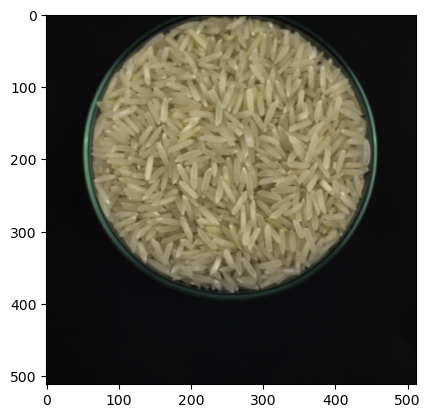

In [3]:
if not os.path.exists(os.path.join(PATH, 'kitchen/basmatiriisi/040.png')):
    print("     Warning: no such file as " + os.path.join(PATH, 'kitchen/basmatiriisi/040.png'))
else:
    image = img.imread(PATH+'kitchen/basmatiriisi/040.png')
    plt.imshow(image)

### The mixed samples

In the Kitchen dataset here are four images in total that have six different substances in each. The substances in the pictures are not labeled, so the pictures are labeled below.

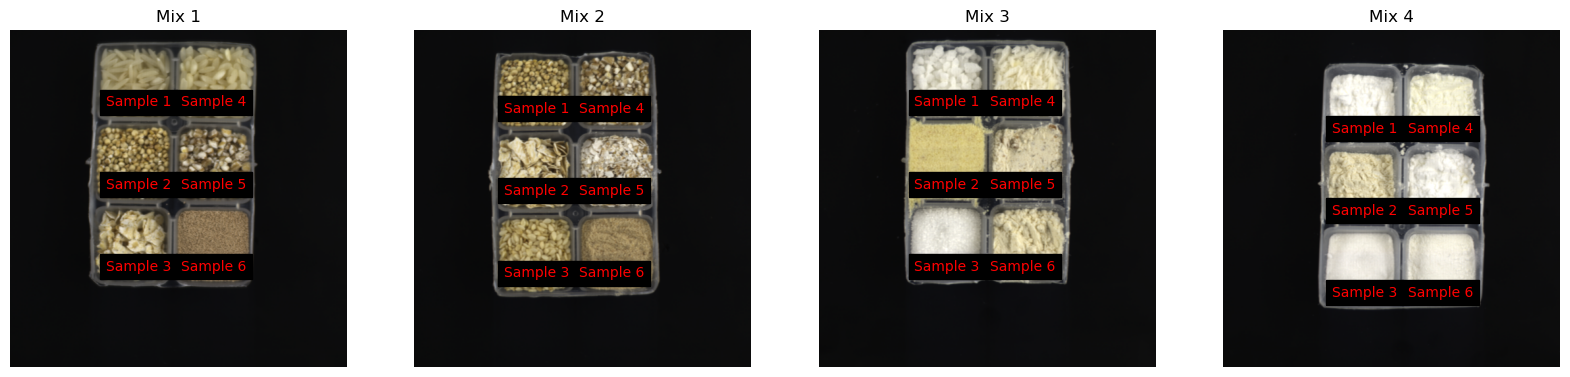

In [64]:
mix1 = img.imread(PATH+'kitchen/sekoite1/sekoite1.png')
mix2 = img.imread(PATH+'kitchen/sekoite2/sekoite2.png')
mix3 = img.imread(PATH+'kitchenday2/sekoitus3/071.png')
mix4 = img.imread(PATH+'kitchenday2/sekoitus4/072.png')

coords1x = [185, 185, 185, 300, 300, 300]
coords1y = [75, 200, 325, 75, 200, 325]
coords2x = [205, 205, 205, 320, 320, 320]
coords2y = [115, 240, 365, 115, 240, 365]

plt.figure().set_size_inches(20, 5)
plt.subplot(1, 4, 1)
plt.title("Mix 1")
for i in range(len(coords1x)):
    plt.annotate(f"Sample {i+1}", xy=(coords1x[i], coords1y[i]), xytext=(coords1x[i]-40, coords1y[i]+40), fontsize=10, color="red", backgroundcolor="black")
plt.axis("off")
plt.imshow(mix1)
plt.subplot(1, 4, 2)
plt.title("Mix 2")
for i in range(len(coords1x)):
    plt.annotate(f"Sample {i+1}", xy=(coords1x[i], coords1y[i]), xytext=(coords1x[i]-50, coords1y[i]+50), fontsize=10, color="red", backgroundcolor="black")
plt.axis("off")
plt.imshow(mix2)
plt.subplot(1, 4, 3)
plt.title("Mix 3")
for i in range(len(coords1x)):
    plt.annotate(f"Sample {i+1}", xy=(coords1x[i], coords1y[i]), xytext=(coords1x[i]-40, coords1y[i]+40), fontsize=10, color="red", backgroundcolor="black")
plt.axis("off")
plt.imshow(mix3)
plt.subplot(1, 4, 4)
plt.title("Mix 4")
for i in range(len(coords1x)):
    plt.annotate(f"Sample {i+1}", xy=(coords2x[i], coords2y[i]), xytext=(coords2x[i]-40, coords2y[i]+40), fontsize=10, color="red", backgroundcolor="black")
plt.axis("off")
plt.imshow(mix4)

**Mix 1:** \
Sample 1: Basmati rice \
Sample 2: Quinoa \
Sample 3: Oat meal \
Sample 4: Porridge rice \
Sample 5: Steel-cut barley \
Sample 6: Dry yeast

**Mix 2:** \
Sample 1: Quinoa \
Sample 2: Oat meal \
Sample 3: Sesame seeds \
Sample 4: Steel-cut barley \
Sample 5: Barley flakes \
Sample 6: Psyllium

**Mix 3:** \
Sample 1: Hail sugar \
Sample 2: Durum wheat flour \
Sample 3: Granulated sugar \
Sample 4: Coconut flakes \
Sample 5: Flour mixture \
Sample 6: Semi-coarse wheat flour

**Mix 4:** \
Sample 1: Powdered sugar \
Sample 2: Semi-coarse wheat flour \
Sample 3: Baking soda \
Sample 4: Corn starch \
Sample 5: Potato flour \
Sample 6: Baking powder


### Preprocessing

The images need to be preprocessed before they can be reliably used in research. A simple way of preprocessing is cropping the photo to reduce the amount of unnecessary data. Like you can see in the photo above, the black background can be cropped a lot. There might also be unintentional noise or offset in the data. This is why the capture folder contains images labelled `WHITEREF_[nr]` and `DARKREF_[nr]`. These images are used to remove the possible noise or offset as thoroughly as possible, and to get an idea of the sensor's sensitivity to light.

The noise cancellation and offset removal happens by subtracting the dark reference from the raw data and then dividing the result with the raw data subtracted from the white reference. This is done in the helper function `load_and_compute_reflectance`.

<br>

Necessary helper functions:

In [4]:
def get_file_paths(path):
    """
    Gets the paths to the folders and files, and the file numbers in the kitchen dataset.
    
    Parameters
    ----------
    path : string
        the path to the folder with the kitchen dataset in it.

    Returns
    ----------
    folders : list of strings or an empty list
        the names of the folders in the base folder

    nums : list of strings or an empty list
        the numbers of the kitchen dataset images
    """
    folders = []
    nums = []
    base_folders = sorted(os.listdir(path))

    # Gathers the names of folders inside the folders inside the base directory.
    for b in base_folders:
        [folders.append(b+'/'+f+'/') for f in sorted([f for f in os.listdir(path+b+'/')])]

    # Gathers the numbers of the image files.
    for f in folders:
        for l in os.listdir(path+f+'metadata/'):
            if l.endswith('.xml'):
                nums.append(str(l.replace('.xml', '')))
    if int(len(folders)) != int(len(nums)):
        print("Warning: couldn't find all file numbers; returning empty arrays.")
        return [], []

    # Removes the images with multiple different substances in one.
    # (As long as they have "sekoitus" or "sekoite" in the file name.)
    i = 0
    while i < len(folders):
        if "sekoit" in folders[i]:
            del folders[i]
            del nums[i]
        else:
            i += 1

    return folders, nums


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def load_and_compute_reflectance(path, folder_name, file_number):
    """
    Loads raw, white and dark reference cubes and computes reflectance.

    Reflectance = (Raw - Dark) / (White - Dark)

    Parameters
    ----------
    path : str
        Path to the folder containing the kitchen and kitchenday2 folders.
    folder_name : str
        Base name shared by all files in this sample.
    file_number : str
        The number associated with the specific sample.
    

    Returns
    -------
    reflectance : ndarray of shape (height, width, bands) or None
        Reflectance cube clipped to [0, 1].
    wavelengths : list of float or None
    """
    folder_path = path + folder_name + '/capture/'
    paths = {
        'raw':   os.path.join(folder_path, f"{file_number}.hdr"),
        'white': os.path.join(folder_path, f"WHITEREF_{file_number}.hdr"),
        'dark':  os.path.join(folder_path, f"DARKREF_{file_number}.hdr"),
    }

    for key, p in paths.items():
        if not os.path.isfile(p):
            print(f"  Missing {key} file: {p}")
            return None, None

    raw, wavelengths = open_image(paths['raw'])
    white, _ = open_image(paths['white'])
    dark, _  = open_image(paths['dark'])

    if any(x is None for x in [raw, white, dark]):
        print("  Failed to load one or more image cubes.")
        return None, None
    
    denominator = white - dark
    denominator[denominator == 0] = 1e-6

    # np.clip: limits the values between given given values, here 0 and 1
    reflectance = np.clip((raw - dark) / denominator, 0, 1)
    return reflectance, wavelengths


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def open_image(file_path):
    """
    Load an ENVI hyperspectral image from disk.

    Parameters
    ----------
    file_path : str
        Path to the .hdr header file.

    Returns
    -------
    data : ndarray of shape (height, width, bands) or None
    wavelengths : list of float or None
    """
    try:
        image = envi.open(file_path)
        data = image.load()

        wavelengths = image.metadata.get('wavelength', None)
        if wavelengths:
            wavelengths = [float(w) for w in wavelengths]

        return data, wavelengths

    except Exception as e:
        print(f"  Error loading {file_path}: {e}")
        return None, None
    

def create_sample_mask(cube, band='mid'):
    """
    Creates a binary mask using Gaussian blur and Otsu thresholding on a single band.

    Parameters
    ----------
    cube : ndarray
        The cube's height, width, bands
    band : string or int
        Band index to threshold.

    Returns
    -------
    mask : ndarray of shape (height, width), dtype uint8
        Binary mask (0 = background, 255 = sample).
    """
    if band == 'min':
        band = min_max_reflectance(cube)[0]
    if band == 'max':
        band = min_max_reflectance(cube)[1]
    if band == 'mid':
        band = min_max_reflectance(cube)[2]

    img = cube[:, :, band]
    img_u8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    blur = cv2.GaussianBlur(img_u8,(5,5),0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return mask


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def segment_sample(cube, mask, margin=5, roi_mode="single", min_roi_area=50):
    """
    Segments the sample region(s) from the background.

    Parameters
    ----------
    cube : ndarray of shape (height, width, bands)
        Reflectance image with values in [0, 1].
    mask : ndarray of shape (height, width), dtype uint8
        Binary mask (0 or 255).
    margin : int
        Pixel margin added around the bounding box.
    roi_mode : {"single", "multiple"}
        ``"single"`` — keep only the largest contour.
        ``"multiple"`` — keep all contours with area >= *min_roi_area*
        (e.g. multiple grains on a tray). The mean spectrum is computed
        over all retained regions jointly.
    min_roi_area : int
        Minimum contour area in pixels (used only in ``"multiple"`` mode).

    Returns
    -------
    segmented : ndarray
        Cropped cube containing only the sample region(s).
    roi_mask : ndarray
        Refined binary mask matching *segmented*.
    """
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("  Warning: no contours found; returning original image.")
        return cube.copy(), mask.copy()

    # Sort by area (largest first)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    roi_mask = np.zeros_like(mask, dtype=np.uint8)

    if roi_mode == "single":
        # Keep the largest contour whose polygon approximation has >= 5 vertices
        for c in contours:
            if len(cv2.approxPolyDP(c, 3, True)) >= 5:
                cv2.fillPoly(roi_mask, [c], 255)
                break
        else:
            # Fallback: use the largest contour regardless
            cv2.fillPoly(roi_mask, [contours[0]], 255)

    elif roi_mode == "multiple":
        for c in contours:
            if cv2.contourArea(c) >= min_roi_area:
                cv2.fillPoly(roi_mask, [c], 255)
    else:
        raise ValueError(f"roi_mode must be 'single' or 'multiple', got '{roi_mode}'")

    # Apply mask (element-wise multiply is correct for float arrays)
    filtered = cube * (roi_mask[:, :, np.newaxis] / 255.0)

    # Crop to bounding box of the combined mask.
    coords = cv2.findNonZero(roi_mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        x = max(0, x - margin)
        y = max(0, y - margin)
        w = min(cube.shape[1] - x, w + 2 * margin)
        h = min(cube.shape[0] - y, h + 2 * margin)
        segmented = filtered[y:y+h, x:x+w]
        roi_mask  = roi_mask[y:y+h, x:x+w]
    else:
        segmented = filtered

    return segmented, roi_mask


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def extract_mean_spectrum(cube, mask):
    """Compute the mean reflectance spectrum over all masked pixels.

    Parameters
    ----------
    cube : ndarray of shape (height, width, bands)
    mask : ndarray of shape (height, width)
        Non-zero pixels are included in the average.

    Returns
    -------
    spectrum : ndarray of shape (bands,)
    """
    pixels = cube[mask > 0]
    if pixels.size == 0:
        print("  Warning: mask is empty; returning zeros.")
        return np.zeros(cube.shape[2])
    return np.mean(pixels, axis=0)


def min_max_reflectance(cube):
    """
    Finds the min, max, and middle reflective band of the spectral cube.

    Parameters
    ----------
    cube : ndarray
        the spectral cube being inspected

    Returns
    ----------
    min : int
        band with the minimum reflectance
    max : int
        band with the maximum reflectance
    mid : int
        band with the middle reclectance
    """
    min = int(np.argmin(np.mean(cube, axis=(0, 1))))
    max = int(np.argmax(np.mean(cube, axis=(0, 1))))
    li = np.mean(cube, axis=(0, 1))
    li.sort()
    mid = len(li)//2
    return min, max, mid


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def gaussian_psf(size=5, sigma=1.0):
    """Generate a normalised 2-D Gaussian point-spread function.

    The PSF models the optical blur of the imaging system and is used as
    input to Richardson-Lucy deconvolution. The optimal *sigma* and
    *num_iter* depend on camera optics and acquisition conditions — there
    is no universal default. Experiment with different values and visually
    compare the deconvolved output to find what works best for your data.

    Parameters
    ----------
    size : int
        Kernel side length in pixels (should be odd).
    sigma : float
        Standard deviation of the Gaussian. Larger values model stronger
        blur. Typical starting range: 0.1 – 2.0.

    Returns
    -------
    psf : ndarray of shape (size, size)
        Normalised kernel (sums to 1).
    """
    psf = np.zeros((size, size))
    psf[size // 2, size // 2] = 1.0
    psf = gaussian_filter(psf, sigma=sigma)
    return psf / psf.sum()


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def apply_richardson_lucy(image, psf, num_iter=15):
    """Apply Richardson-Lucy deconvolution band by band.

    Parameters
    ----------
    image : ndarray of shape (height, width, bands)
    psf : ndarray
        Point-spread function kernel.
    num_iter : int
        Number of iterations. Higher values sharpen the image but may
        amplify noise.

    Returns
    -------
    : ndarray
        Deconvolved image, same shape as input.
    """
    result = np.zeros_like(image)
    for b in range(image.shape[2]):
        result[:, :, b] = richardson_lucy(image[:, :, b], psf, num_iter=num_iter)
    return result


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def process_sample(path, folder_name, file_number, deblur=False, deblur_sigma=0.1, deblur_iter=5, roi_mode="single", min_roi_area=50, margin=5, band='mid'):
    """
    Run the full processing pipeline on one sample.

    Parameters
    ----------
    sample_name : str
    folder_name : str
        Name of the folder containing the ``capture/`` folder.
    deblur : bool
        Apply Richardson-Lucy deconvolution.
    deblur_sigma : float
        Gaussian PSF sigma for deconvolution.
    deblur_iter : int
        Number of deconvolution iterations.
    roi_mode : {"single", "multiple"}
        Passed to ``segment_sample``.
    min_roi_area : int
        Passed to ``segment_sample``.
    margin : int
        Pixel margin around the segmented bounding box.
    band : str
        The band to use in the creation of the sample mask.

    Returns
    -------
    spectrum : ndarray or None
    waves : list or None
    """
    cube, waves = load_and_compute_reflectance(path, folder_name, file_number)

    if deblur:
        psf = gaussian_psf(sigma=deblur_sigma)
        processed = apply_richardson_lucy(cube, psf, num_iter=deblur_iter)
    else:
        processed = cube

    mask = create_sample_mask(processed, band)

    segmented, roi_mask = segment_sample(
        processed, mask, margin=margin,
        roi_mode=roi_mode, min_roi_area=min_roi_area,
    )
    
    plt.imshow(roi_mask)
    plt.show()

    spectrum = extract_mean_spectrum(segmented, roi_mask)

    return spectrum, waves


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def multiplicative_scatter_correction(spectra, reference=None):
    """
    Apply Multiplicative Scatter Correction (MSC).

    Each spectrum is linearly regressed against a reference spectrum and
    the fitted slope/intercept are used to remove multiplicative and
    additive scatter effects.

    Parameters
    ----------
    spectra : ndarray of shape (n_samples, n_wavelengths)
    reference : ndarray of shape (n_wavelengths,) or None
        If None the mean of *spectra* is used.

    Returns
    -------
    corrected : ndarray, same shape as *spectra*
    reference : ndarray of shape (n_wavelengths,)
        The reference spectrum used. Save this to apply the same
        correction to new data later.
    """
    if reference is None:
        reference = np.mean(spectra, axis=0)

    corrected = np.zeros_like(spectra)
    for i in range(len(spectra)):
        coeffs = np.polyfit(reference, spectra[i], 1)
        corrected[i] = (spectra[i] - coeffs[1]) / coeffs[0]

    return corrected, reference


def std_deviation(cube, mask):
    """
    Returns the standard deviations of the spectral bands in the cube.

    Parameters
    ----------
    cube : ndarray
        the spectral cube being examined
    mask : ndarray
        the mask for the spectral cube

    Returns
    ----------
    : ndarray
        the standard deviations of the spectral bands
    """
    pixels = cube[mask > 0]
    if pixels.size == 0:
        print("  Warning: mask is empty; returning zeros.")
        return np.zeros(cube.shape[2])
    return np.std(pixels, axis=0)

The function `get_file_paths` gets the paths of all of the hyperspectral raw images in the `kitchen` and `kitchenday2` folders, dropping the images with multiple substances.

In [5]:
folders, nums = get_file_paths(PATH)

print(f'Found {len(folders)} folders:')
for f in folders:
    print("    ", f)

Found 23 folders:
     kitchen/basmatiriisi/
     kitchen/kaurahiutale1min/
     kitchen/kuivahiiva/
     kitchen/kvinoa/
     kitchen/ohrahiutale_kasittelematon/
     kitchen/psyllium/
     kitchen/puuroriisi/
     kitchen/rikottu_ohrasuurimo/
     kitchen/seesaminsiemen/
     kitchenday2/durumvehna/
     kitchenday2/jodioitu_suola/
     kitchenday2/karkea_vehnajauho/
     kitchenday2/kookoshiutale/
     kitchenday2/leivinjauhe/
     kitchenday2/maizena/
     kitchenday2/merisuola/
     kitchenday2/perunajauho/
     kitchenday2/puolikarkea_vehnajauho/
     kitchenday2/raesokeri/
     kitchenday2/sampylajauho/
     kitchenday2/sokeri/
     kitchenday2/sooda/
     kitchenday2/tomusokeri/


English names of the substances:

|Finnish   |English   |
|----------|----------|
|basmatiriisi|basmati rice|
|kaurahiutale, 1 min|1-minute oatmeal|
|kuivahiiva|dry yeast|
|kvinoa|quinoa|
|ohrahiutale, käsittelemätön|unprocessed barley flakes|
|psyllium|psyllium|
|puuroriisi|porridge rice|
|rikottu ohrasuurimo|steel-cut barley|
|seesaminsiemen|sesame seed|
|durumvehnä|durum wheat flour|
|jodioitu suola|iodized salt|
|karkea vehnäjauho|coarse wheat flour|
|kookoshiutale|coconut flakes|
|leivinjauhe|baking powder|
|maizena|Maizena corn startch|
|merisuola|seasalt|
|perunajauho|potato flour|
|puolikarkea vehnäjauho|semi-coarse wheat flour|
|raesokeri|hail sugar|
|sämpyläjauho|bread flour|
|sokeri|granulated sugar|
|sooda|baking soda|
|tomusokeri|powdered sugar|

<br>

Running the code below opens a UI that helps to look through the different layers (bands) of the spectral cubes. This can be useful in noticing issues in the bands that can negatively affect the mask forming and the machine learning later on. For example, most of the images in `kitchenday2` have a reflection in the higher layers that distorts the masks, which is why those layers can't be used in forming the masks.

(You can click on the circle on the slider to use the arrow keys of your keyboard to control the slider, or click on the number next to the slider to type in a number.)

In [6]:
cubes = []
for i, folder in enumerate(folders):
    cube, _ = load_and_compute_reflectance(PATH, folder, nums[i])
    cubes.append(cube)

def interactive_pic(cube, layer):
    for i, folder in enumerate(folders):
        if cube == folder:
            c = cubes[i]
    plt.imshow(c[:,:,layer])
    plt.show()

interact(interactive_pic, cube=folders, layer=(0, 203, 1))

/tmp/ipykernel_1321839/3144728661.py:91: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_1321839/3144728661.py:95: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


interactive(children=(Dropdown(description='cube', options=('kitchen/basmatiriisi/', 'kitchen/kaurahiutale1min…

<function __main__.interactive_pic(cube, layer)>

A part of the preprocessing process is to also form masks for the images. In this case, the binary masks mark the area of the substance being examined. It is possible and sometimes necessary to form the masks by hand, but in this case, since the images have been taken against a solid-colored background, adequate masks can be formed using Otsu tresholding.

<br>

The following code forms and prints the masks. It is a good idea to look through the masks to make sure they look alright. Sometimes there may be reflections or other irregularities that may affect the size and shape of the mask.

If there happens to be such an irregularity, the variable `band` in the helper function `create_sample_mask` may be adjusted. It is set to `min_max_reflectance(cube)[1]`, which is the median mean reflectance of the samples.

Found 23 sample(s)

[1/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/capture/


/tmp/ipykernel_1321839/3144728661.py:91: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_1321839/3144728661.py:95: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


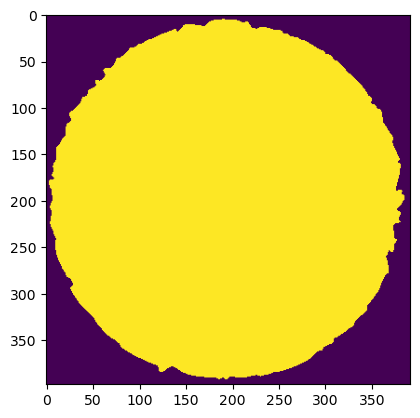

[2/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/kaurahiutale1min/capture/


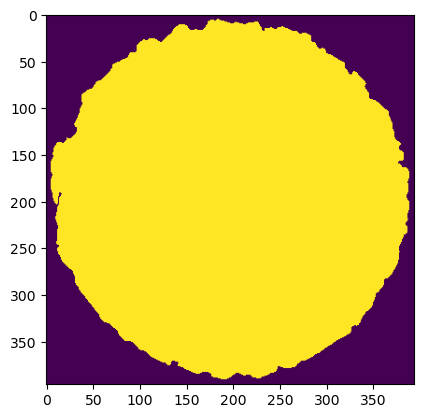

[3/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/kuivahiiva/capture/


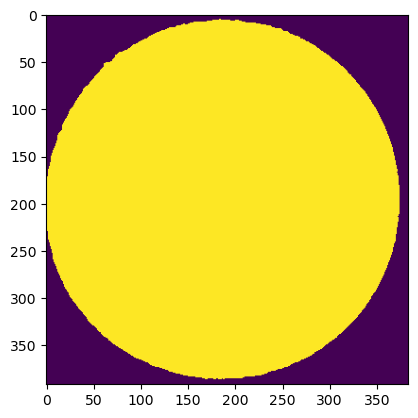

[4/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/kvinoa/capture/


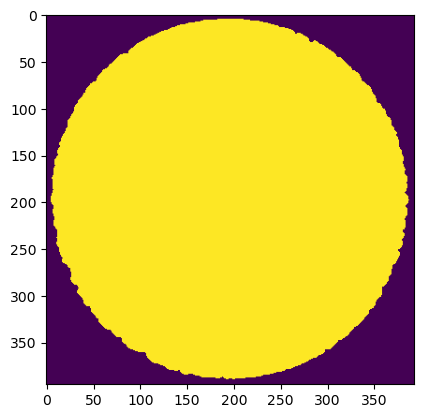

[5/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/ohrahiutale_kasittelematon/capture/


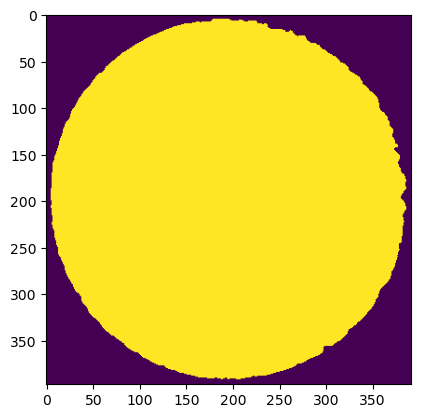

[6/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/psyllium/capture/


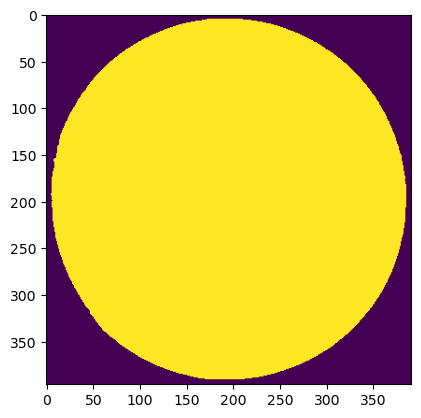

[7/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/puuroriisi/capture/


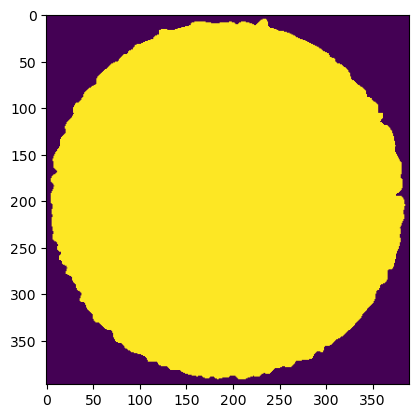

[8/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/rikottu_ohrasuurimo/capture/


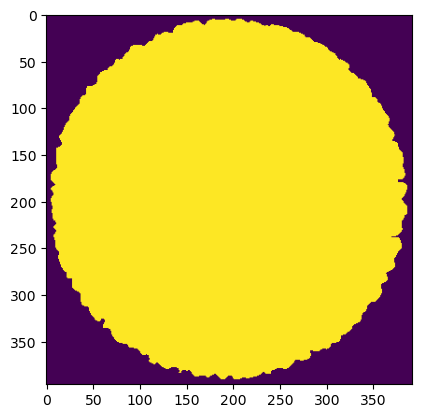

[9/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/seesaminsiemen/capture/


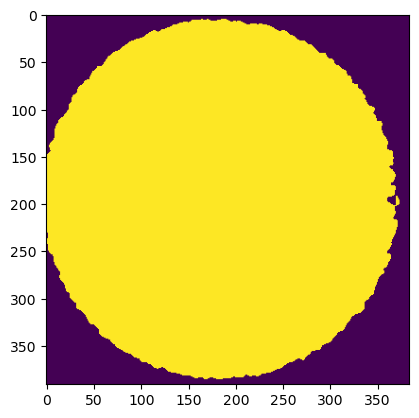

[10/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/durumvehna/capture/


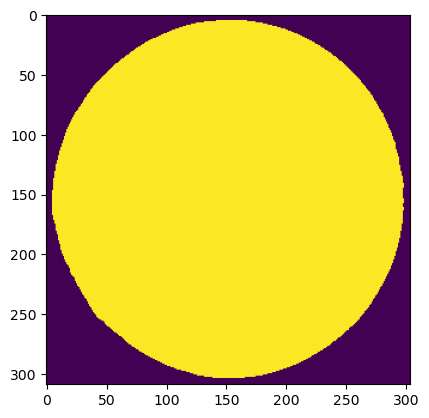

[11/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/jodioitu_suola/capture/


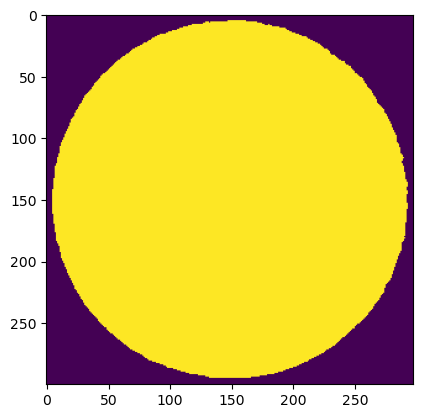

[12/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/karkea_vehnajauho/capture/


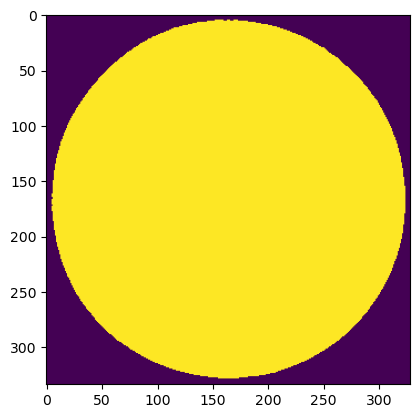

[13/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/kookoshiutale/capture/


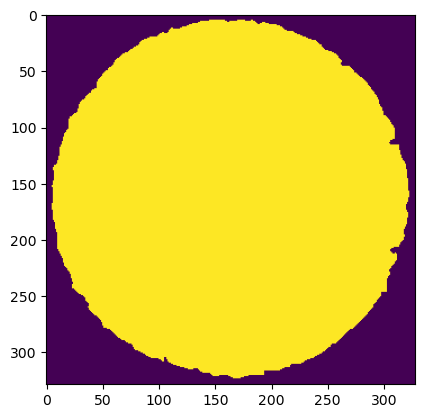

[14/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/leivinjauhe/capture/


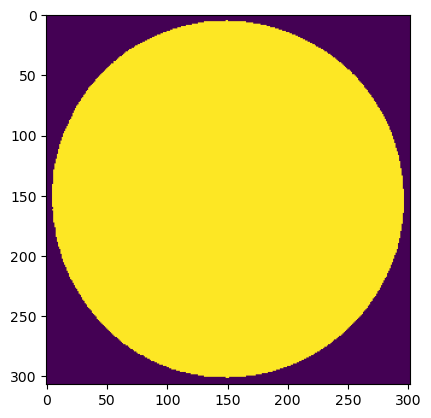

[15/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/maizena/capture/


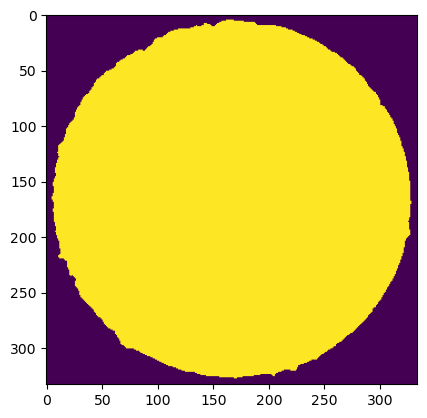

[16/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/merisuola/capture/


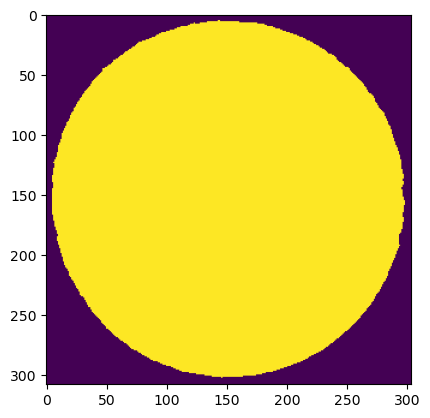

[17/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/perunajauho/capture/


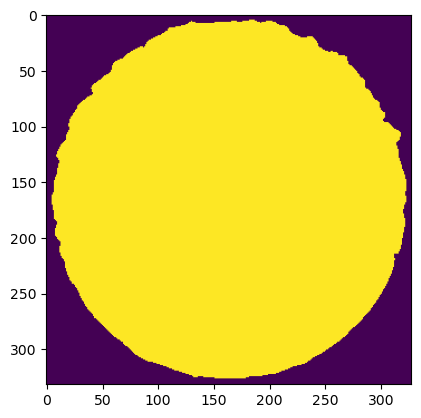

[18/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/puolikarkea_vehnajauho/capture/


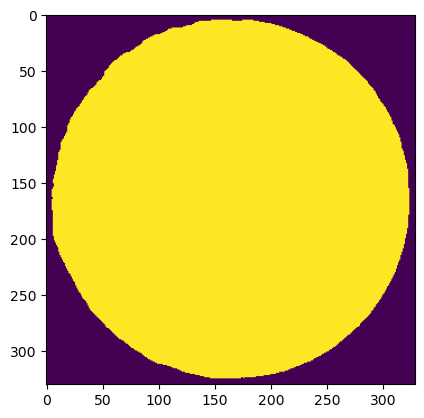

[19/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/raesokeri/capture/


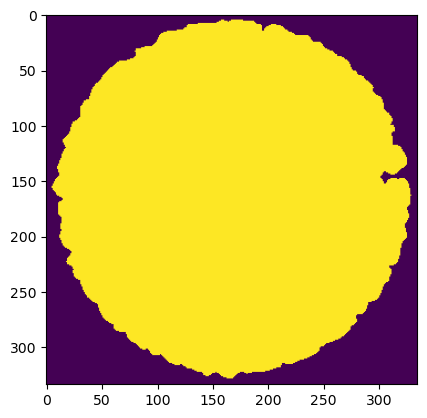

[20/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/sampylajauho/capture/


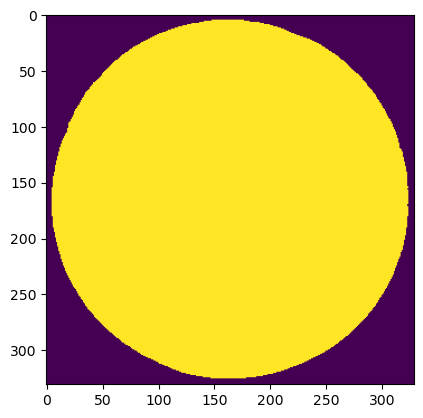

[21/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/sokeri/capture/


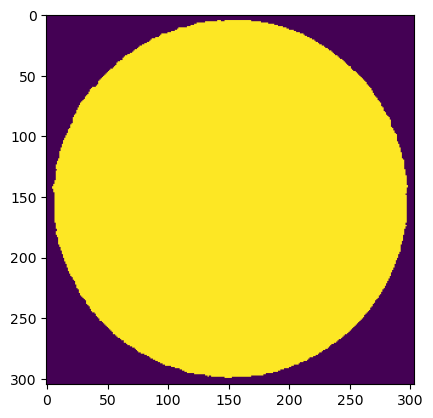

[22/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/sooda/capture/


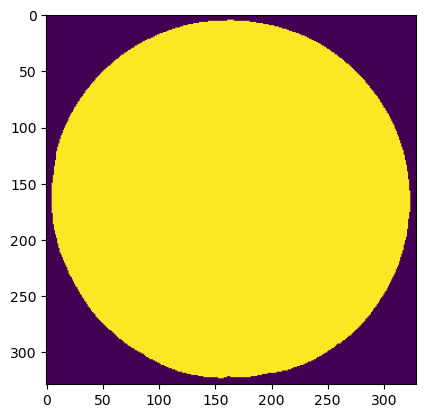

[23/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/tomusokeri/capture/


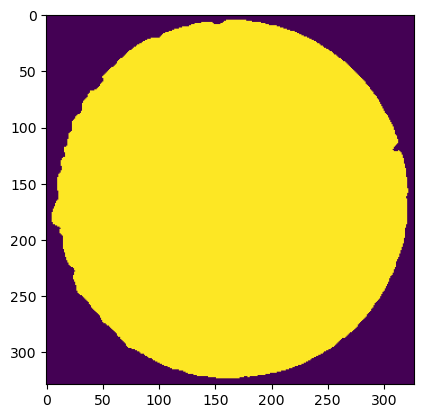


Processed 23/23 samples successfully.


In [7]:
print(f"Found {len(folders)} sample(s)\n")

spectra = []
wavelengths = None

for i, folder in enumerate(folders, 1):
    print(f"[{i}/{len(folders)}] ", end="")
    capture = os.path.join(PATH, folder, "capture/")
    print(capture)

    if not os.path.isdir(capture):
        print(f"  Skipping {folder}: no 'capture' subfolder.")
        continue

    spec, wl = process_sample(PATH, folder, nums[i-1])
    if spec is not None:
        spectra.append(spec)
        if wavelengths is None:
            wavelengths = wl


print(f"\nProcessed {len(spectra)}/{len(folders)} samples successfully.")

Now, the used wavelengths are saved in a list called `wavelengths`, the mean reflectance values of the samples in a list called `spectra` and the spectral cubes in a list called `cubes`.

<br>


# Visualization

Below, is a plot of the mean spectra of the samples. It is easy to see many clear differences and similarities between the graphs.

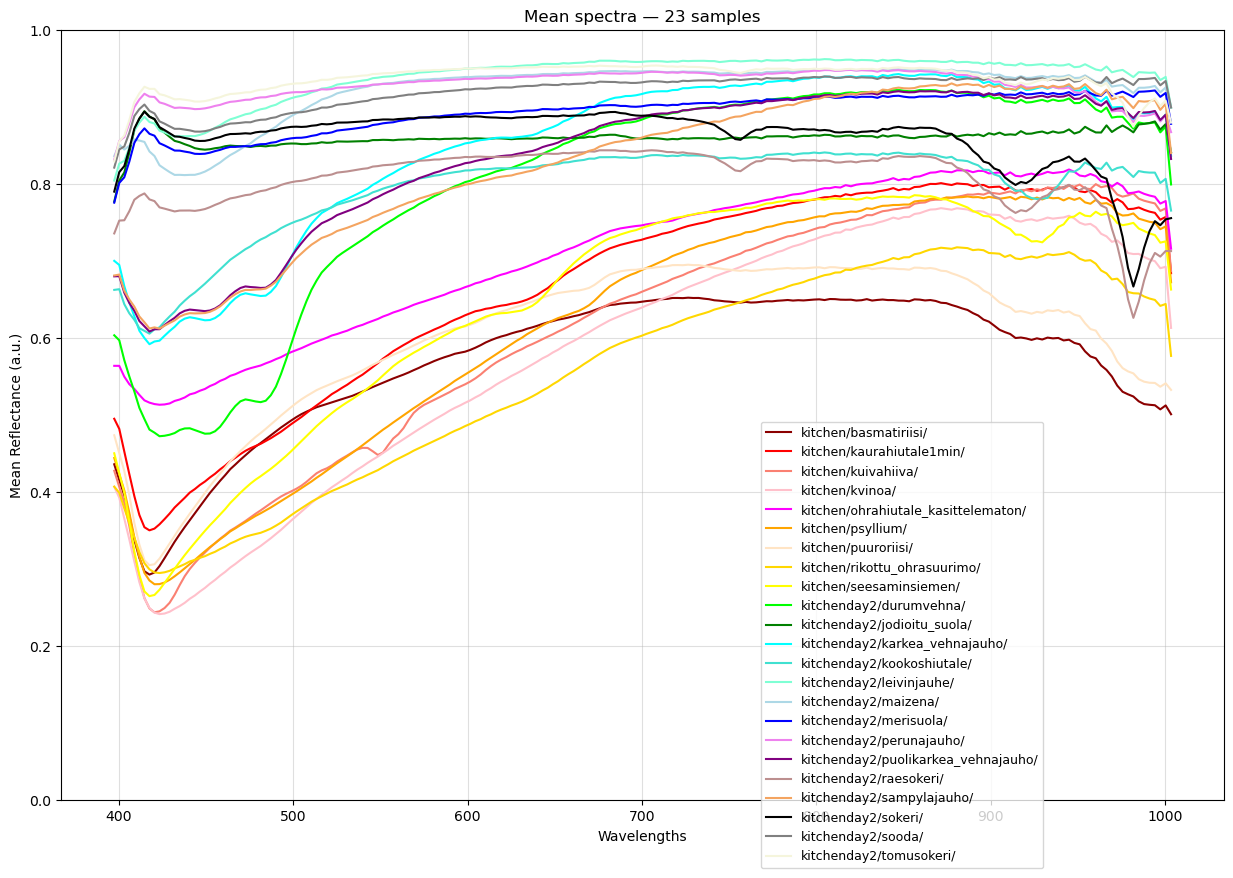

In [8]:
colors = ['darkred', 'red', 'salmon', 'pink', 'magenta', 'orange', 'bisque', 'gold', 'yellow', 'lime', 'green', 'cyan', 'turquoise', 'aquamarine', 'lightblue', 'blue', 'violet', 'purple', 'rosybrown', 'sandybrown', 'black', 'gray', 'beige']

array = np.array(spectra)
plt.figure().set_size_inches(15,10)

for i, a in enumerate(array):
    plt.plot(wavelengths, a, color=colors[i])

plt.grid(visible=True, alpha=0.4)
plt.title(f"Mean spectra — {len(spectra)} samples")
plt.xlabel('Wavelengths')
plt.ylabel('Mean Reflectance (a.u.)')
plt.legend(folders, fontsize=9, bbox_to_anchor=(0.85,0.5))
plt.ylim(0, 1)
plt.show()

One way to also process spectral data is to use Multiplicative Scatter Correction (MSC). It is used to correct multiplicative deviations caused by light scattering from the sample. MSC aims to minimize the affects of these deviations by fitting a linear model between a reference spectrum and other spectra of the dataset using the linear least squares method. Usually, the reference spectrum chosen is the average of all of the spectra in the dataset. After the appliance of MSC, all of the spectra appear to have the same absorbance level.

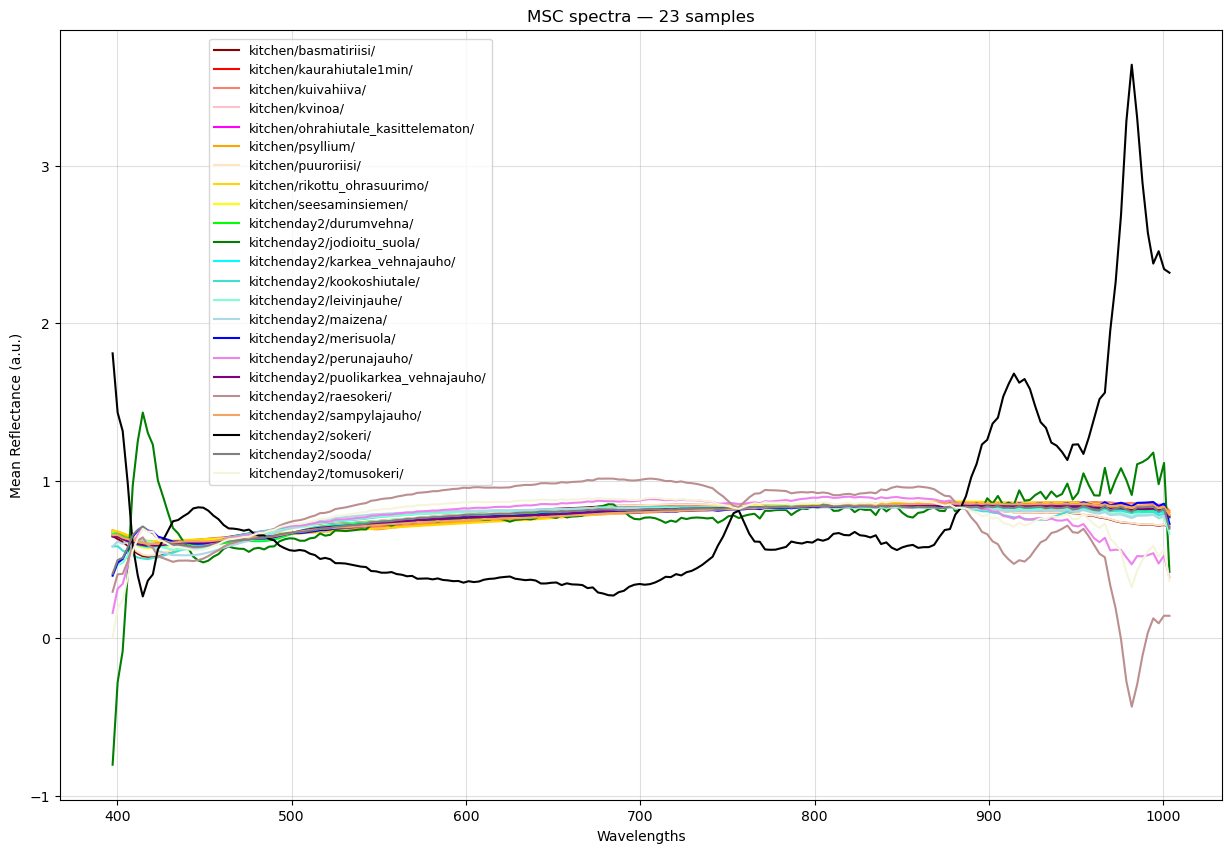

In [9]:
spectra_msc, ref_spectrum = multiplicative_scatter_correction(spectra)

plt.figure().set_size_inches(15,10)

for i, a in enumerate(spectra_msc):
    plt.plot(wavelengths, a, color=colors[i])

plt.grid(visible=True, alpha=0.4)
plt.title(f"MSC spectra — {len(spectra)} samples")
plt.xlabel('Wavelengths')
plt.ylabel('Mean Reflectance (a.u.)')
plt.legend(folders, fontsize=9, bbox_to_anchor=(0.25,0.4))
plt.show()

The next piece of code prints out the mean spectra and standard deviations of the spectra one-by-one.

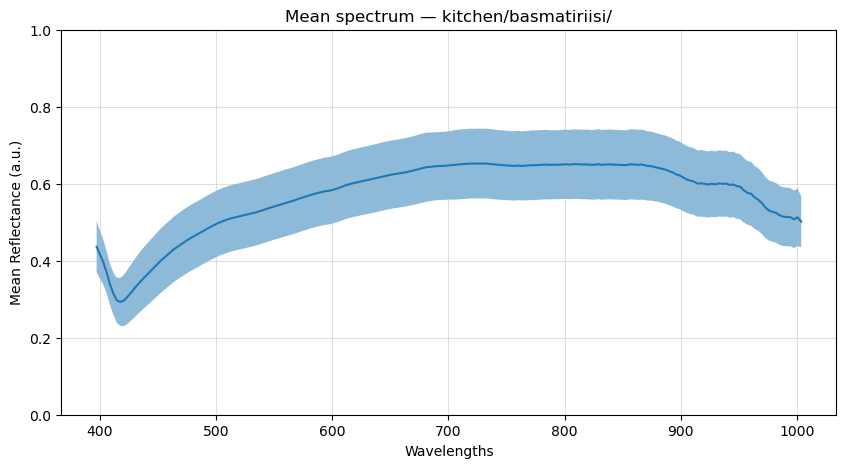

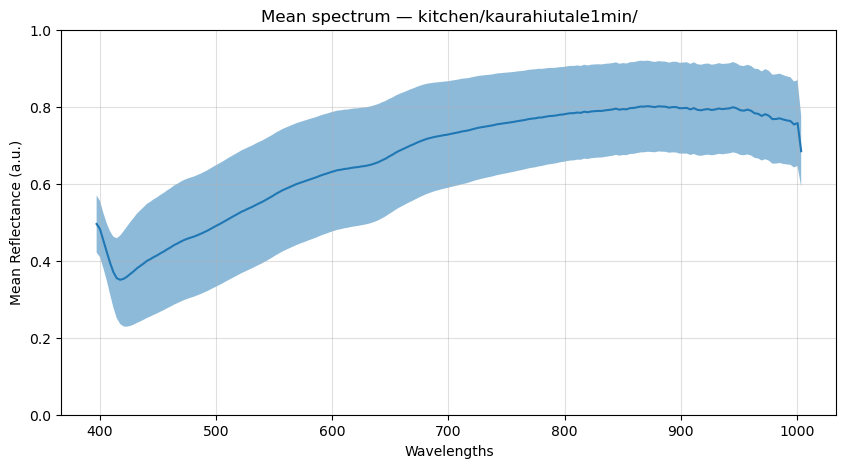

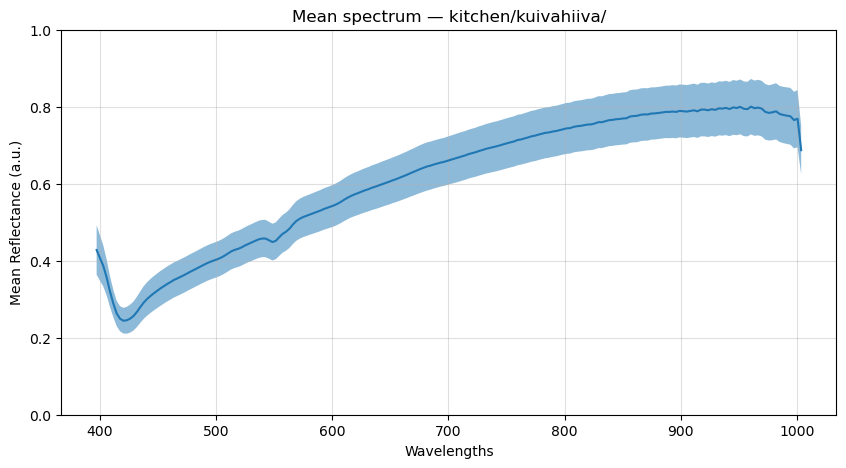

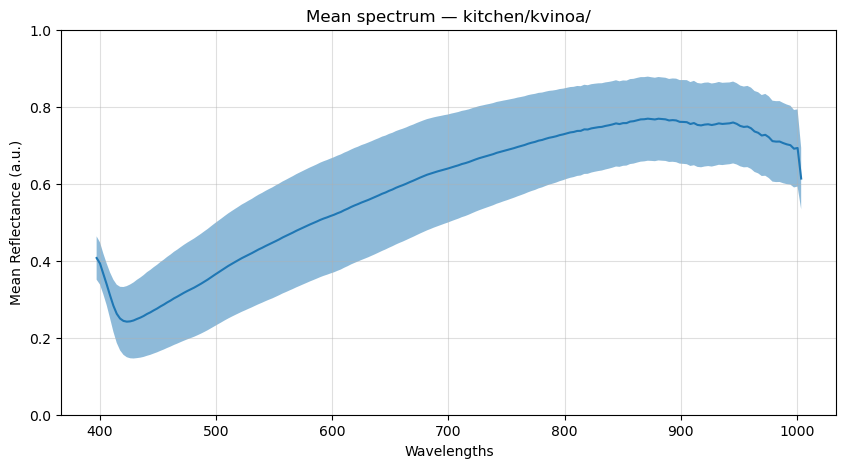

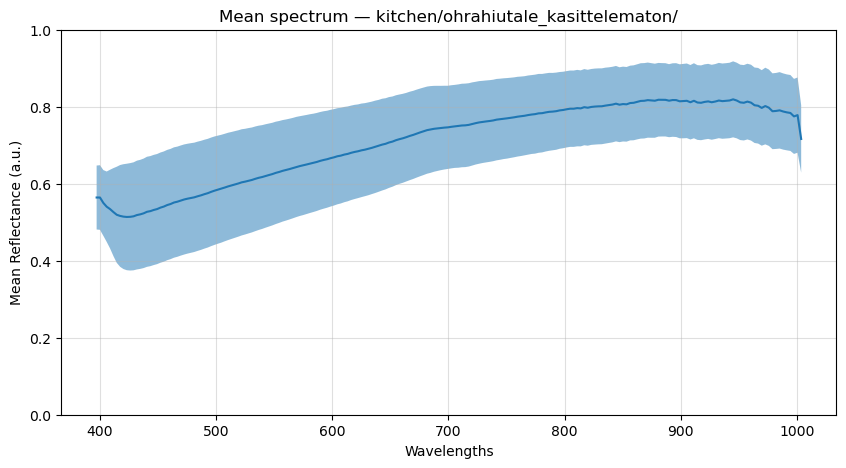

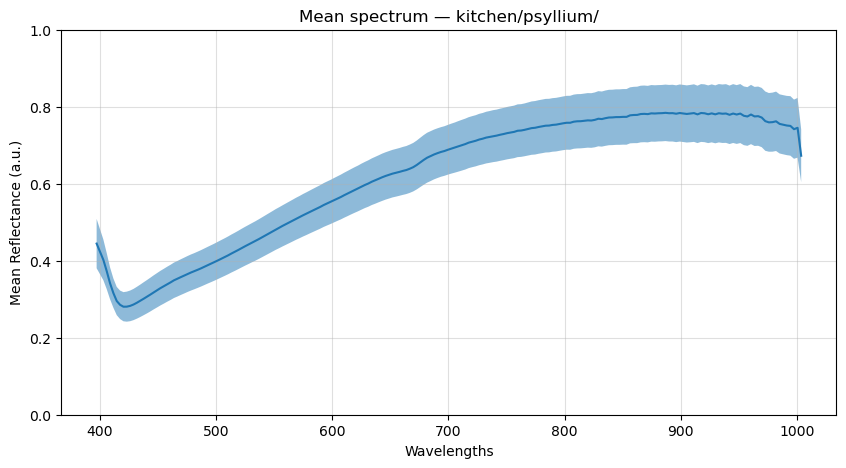

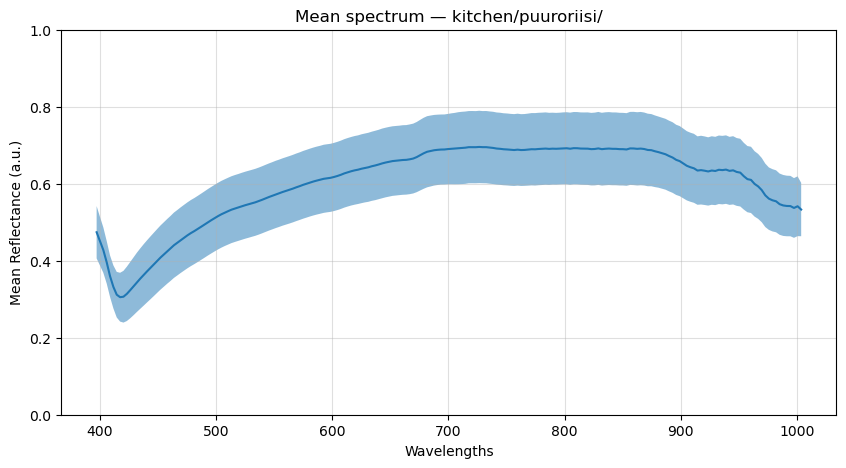

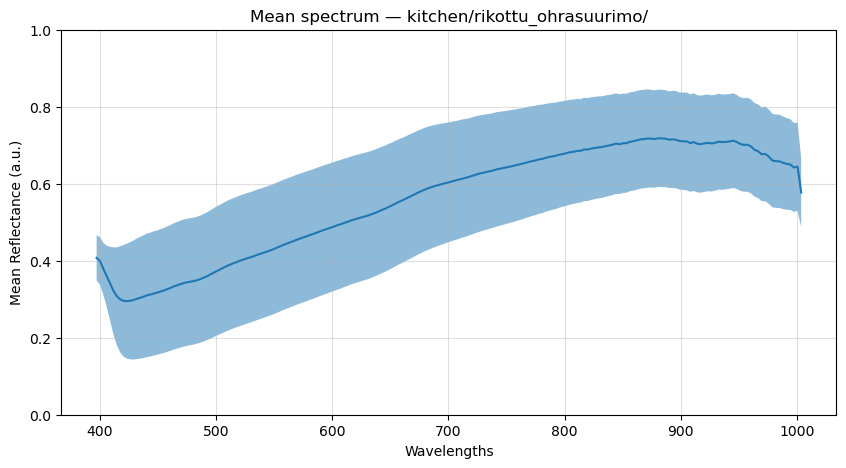

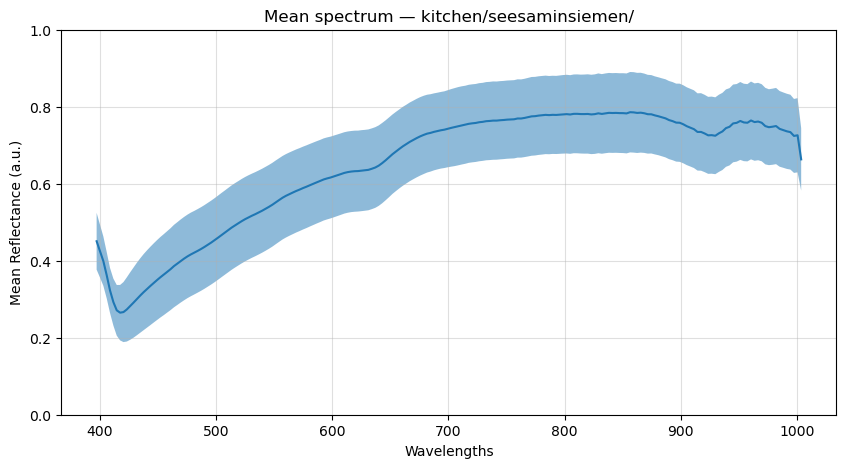

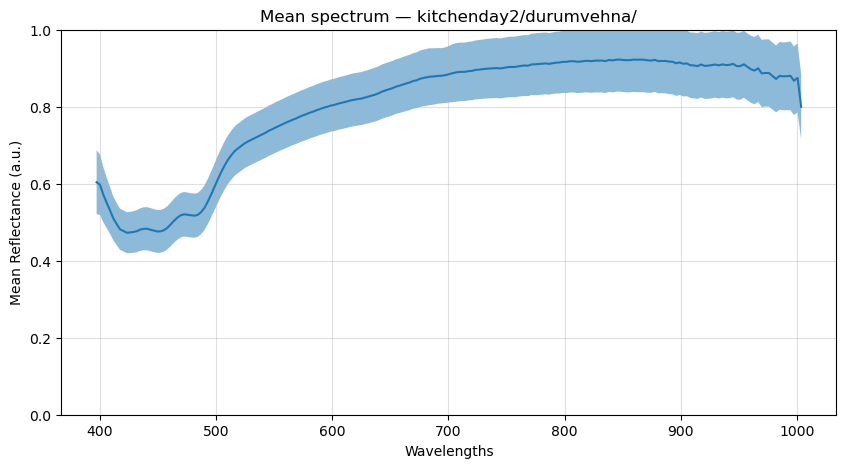

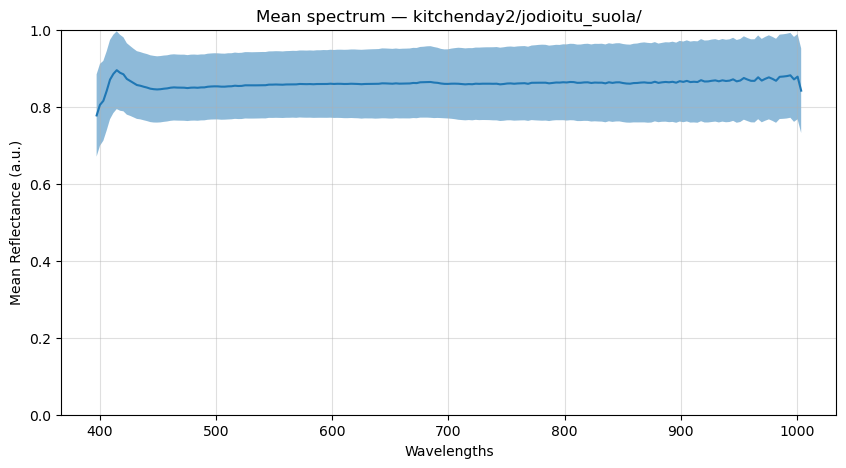

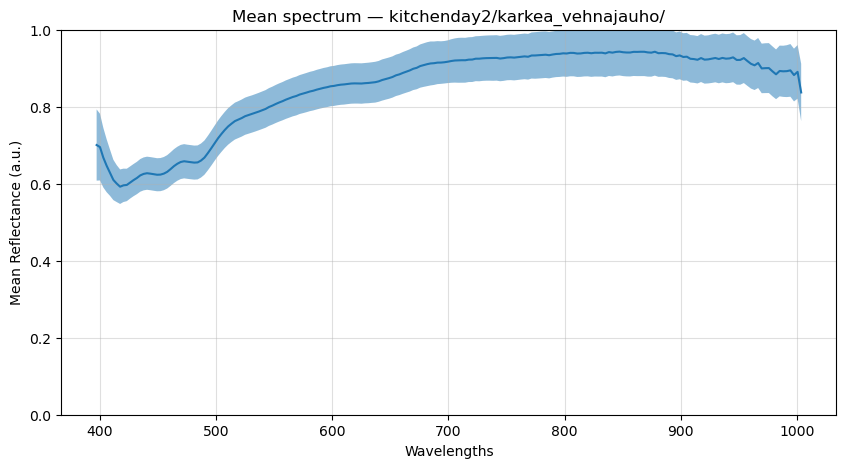

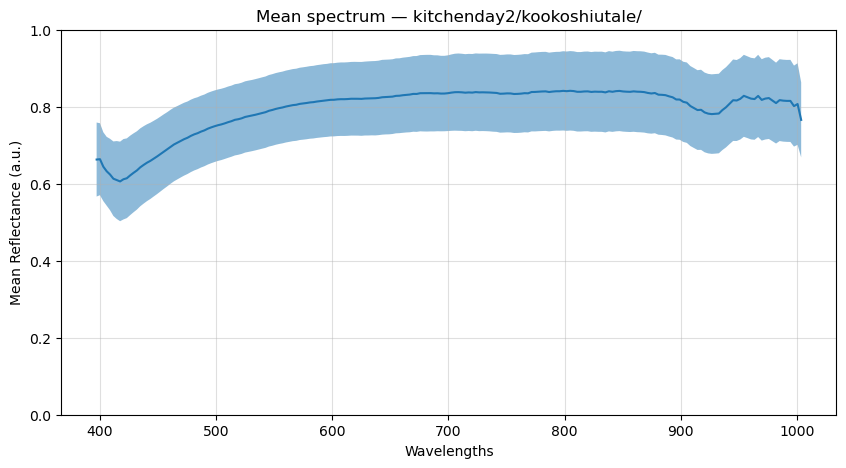

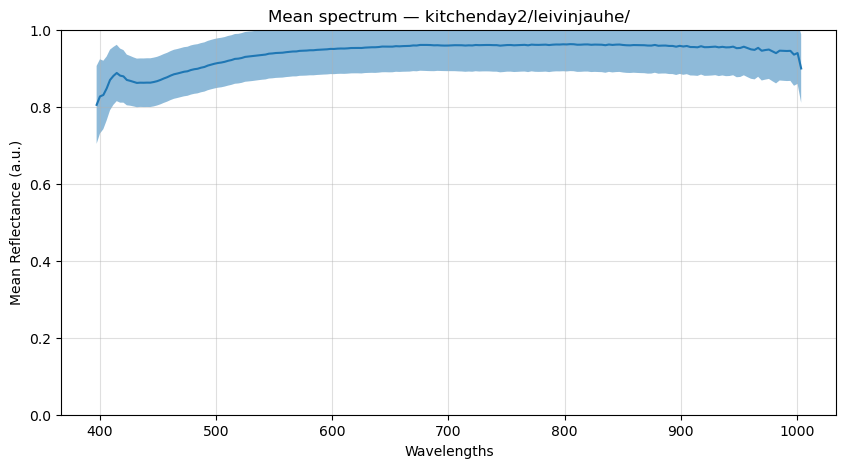

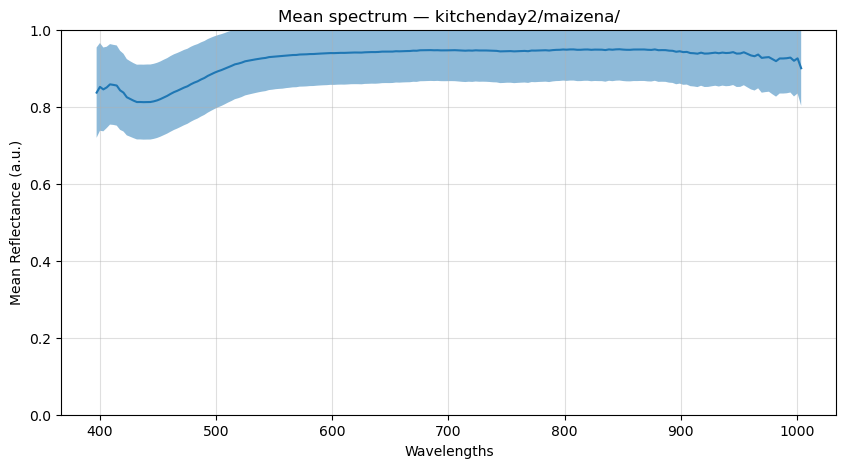

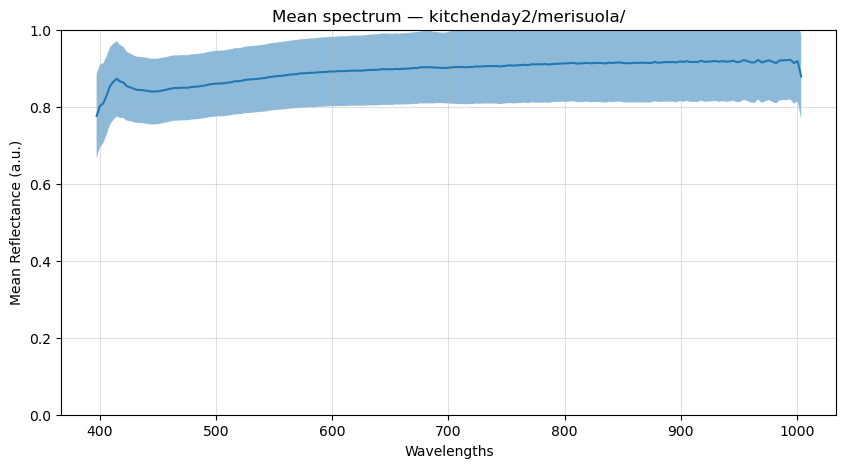

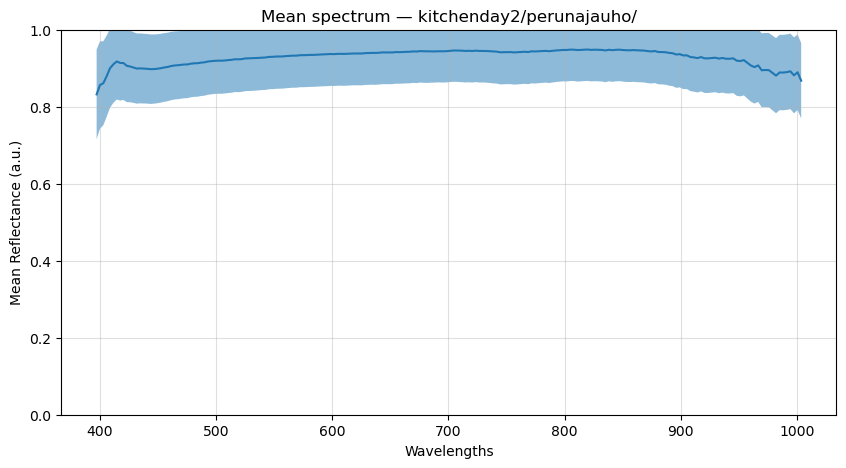

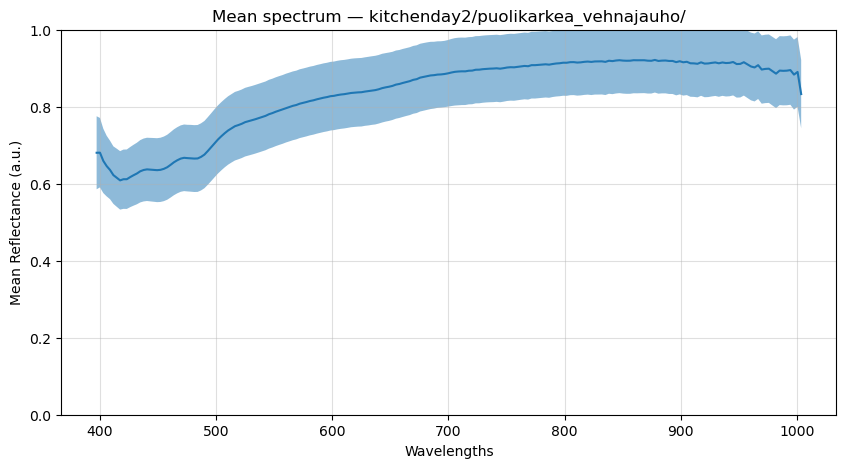

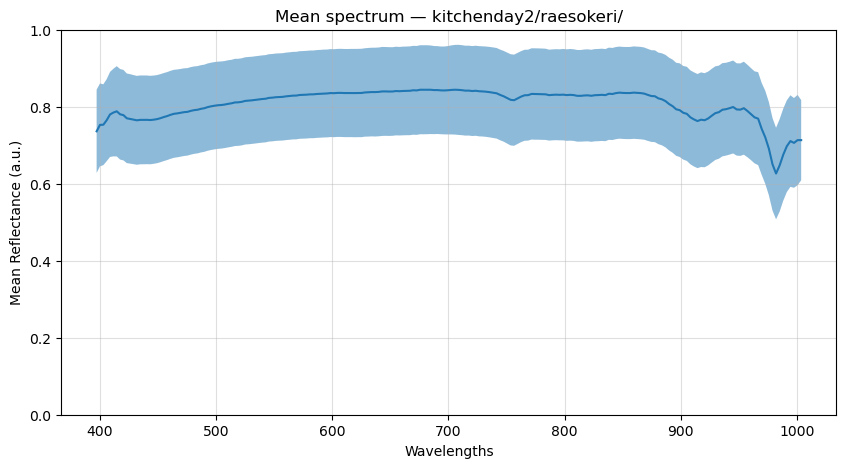

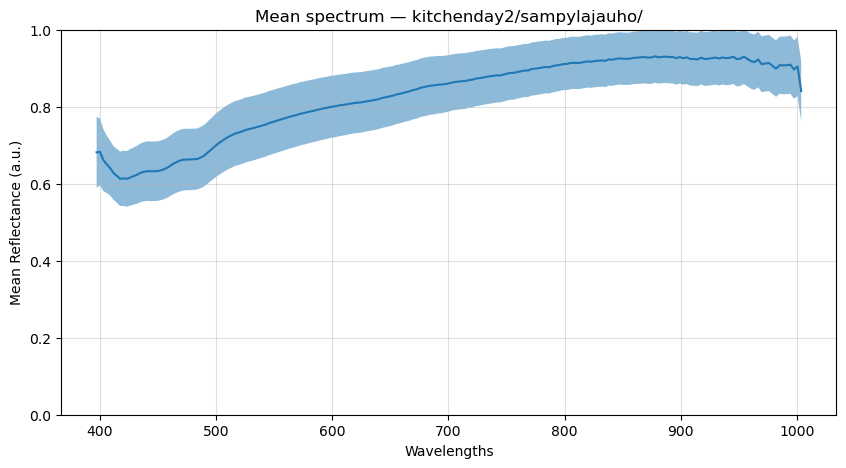

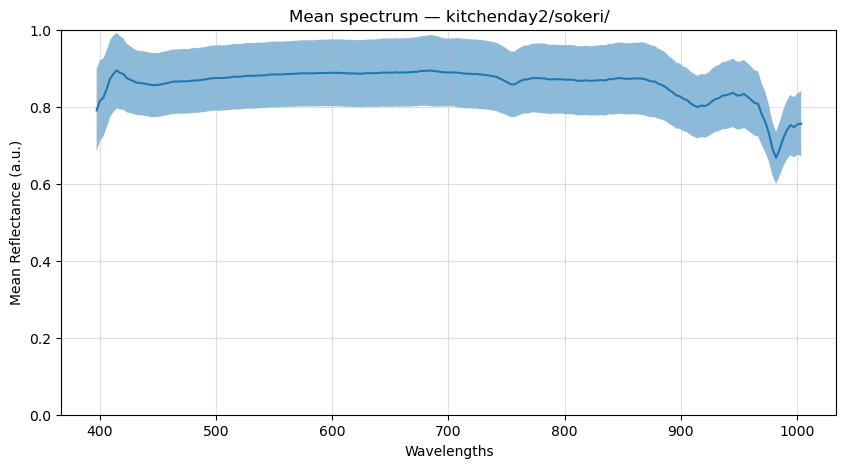

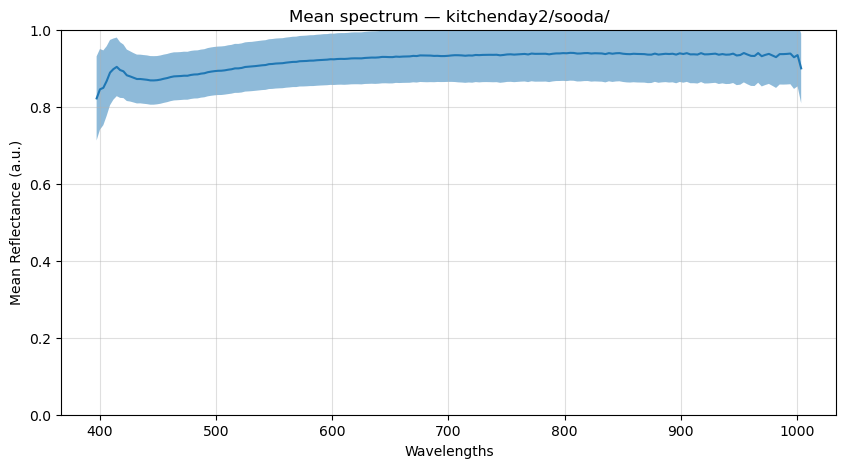

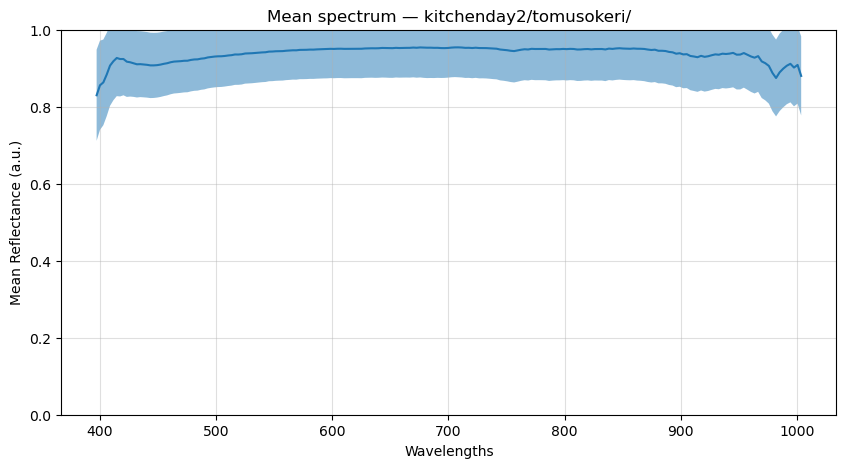

In [10]:
deviations = []

for cube in cubes:
    mask = create_sample_mask(cube)
    segmented, roi_mask = segment_sample(cube, mask)

    deviations.append(std_deviation(segmented, roi_mask))


for i, a in enumerate(array):
    plt.figure().set_size_inches(10,5)
    plt.plot(wavelengths, a)
    plt.fill_between(wavelengths, a-deviations[i], a+deviations[i], alpha = 0.5, label='_nolegend_')
    plt.grid(visible=True, alpha=0.4)
    plt.title(f"Mean spectrum — {folders[i]}")
    plt.xlabel('Wavelengths')
    plt.ylabel('Mean Reflectance (a.u.)')
    plt.ylim(0, 1)
    plt.show()

In [11]:
_, wavelengths = load_and_compute_reflectance(PATH, folders[0], nums[0])

image_cubes = []
masks = []

for n in range(len(folders)):
    cube, _ = load_and_compute_reflectance(PATH, folders[n], nums[n])
    mask = create_sample_mask(cube)
    image_cubes.append(cube)
    masks.append(mask)

/tmp/ipykernel_1321839/3144728661.py:91: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_1321839/3144728661.py:95: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


# Machine learning

Now that the data has been processed, it can be used for machine learning. For the following code to work, the following variables need to exist:

- `spectra` : a list of the mean spectra of the samples.
- `wavelengths` : a list of the wavelengths as strings.
- `image_cubes` : a list of the spectral cubes as `(rows, columns, bands)` ndarrays.
- `masks` : a list of the binary sample masks.

Below are a couple more helper functions.

Also, some of the previous helper functions are necessary.

In [12]:
def estimate_model(model, X_test, y_test):
    """
    Estimates the accuracy of a given machine learning model.

    Parameters
    ----------
    model : a machine learning model
        The fitted model.
    X_test : ndarray
        Testing data for the model.
    y_test : ndarray
        True values for accuracy testing.

    Returns
    -----------
    y_pred : ndarray
        Predicted values.
    """
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"accuracy: {round(accuracy,2)}")
    print(classification_report(y_test, y_pred))

    return y_pred


def print_confusion_matrix(y_test, y_pred):
    """
    Prints the confusion matrix of given data.

    Parameters
    ----------
    y_test : ndarray
        True values.
    y_pred : ndarray
        Predicted values.
    """
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(15, 15))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


def optimize(model, param_grid, X_train, y_train):
    """
    Uses the grid search method to optimize the parameters of a machine learning model.

    Parameters
    ----------
    model : a machine learning model
        The model to be optimized.
    param_grid : dict
        The parameters and their alternative values to be tested during the optimization.
    X_train : ndarray
        The measured training data for fitting a machine learning model.
    y_train : ndarray
        The true values of the training data for fitting a machine learning model.
    """
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, verbose=True)
    grid_search.fit(X_train, y_train)

    print("best accuracy", grid_search.best_score_)
    print(grid_search.best_estimator_)

    return grid_search.best_estimator_

Next is the sampling for the machine learning. The seed of the randomizer can be changed below (or removed for a random seed), as well as the sample size. By default, 1000 one-pixel samples are picked per substance.

In [64]:
np.random.seed(4)
samples = 1000

names = []
pixels = []

for n in range(len(folders)):
    cube = image_cubes[n]
    mask = masks[n]
    segmented, roi_mask = segment_sample(cube, mask)
    i, j = np.nonzero(roi_mask)
    ix = np.random.choice(len(i), samples, replace=False)   # replace=False makes sure no single pixel is chosen twice.
    pixels = [*pixels, *segmented[i[ix], j[ix],:]]
    names.extend([n for i in range(samples)])

pixels = np.array(pixels).T

The data is next stored in a Pandas DataFrame, where the columns are the values of different bands of light (204 bands), and the rows are the randomly chosen pixels.

In [14]:
df = pd.DataFrame(pixels.T, index=names, columns=wavelengths)
print('The first five rows of the dataframe:\n\n', df[:5])

The first five rows of the dataframe:

     397.32    400.20    403.09    405.97    408.85   411.74    414.63   \
0  0.489362  0.442308  0.423729  0.394366  0.340659    0.320  0.302857   
0  0.510638  0.480769  0.440678  0.408451  0.369565    0.360  0.320000   
0  0.382979  0.365385  0.322034  0.323944  0.315217    0.304  0.285714   
0  0.468085  0.423077  0.406780  0.380282  0.369565    0.336  0.314286   
0  0.489362  0.480769  0.431034  0.408451  0.358696    0.328  0.308571   

    417.52    420.40    423.29   ...   975.79    978.88    981.96    985.05   \
0  0.287500  0.282540  0.290076  ...  0.538462  0.534884  0.530864  0.532468   
0  0.316667  0.311111  0.323155  ...  0.555556  0.546512  0.530864  0.558442   
0  0.295833  0.301587  0.320611  ...  0.538462  0.534884  0.543210  0.519481   
0  0.312500  0.304762  0.323155  ...  0.593407  0.581395  0.580247  0.571429   
0  0.300000  0.301587  0.302799  ...  0.549451  0.511628  0.518519  0.519481   

    988.13    991.22    994.31    

For the data splitting, `train_test_split` from the `Scikit` library is used. To adjust the split, the `test_size` attribute can be altered. Similarly, to change the split seed, the `random_state` attribute can be changed, or removed for a random split every time.

After, the data is standardized.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    df, df.index, test_size=0.25, random_state=42
)

#print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

print('Shape and type of X_train: ', X_train.shape, type(X_train))
print('Shape and type of y_train: ', y_train.shape, type(y_train))

Shape and type of X_train:  (17250, 204) <class 'numpy.ndarray'>
Shape and type of y_train:  (17250,) <class 'numpy.ndarray'>


Next up, different machine learning algorithms will be trained and tested using the training and testing data. For each of the models, the random state seed has been set, so the results are comparable and will stay the same every time the code is run.

The grid search method was used to find the optimal parameters for the algorithm. This does take time, sometimes even hours, which is why the best models are saved in the `models` folder and loaded for use from there. There is also commented code for those who want to try fitting different models themselves. The random state is set.

## Logistic regression

In [16]:
lr_model = joblib.load('models/lr_model.pkl')
# lr_model = LogisticRegression(random_state=4)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,4
,solver,'newton-cg'
,max_iter,3000
,multi_class,'deprecated'


In [17]:
y_pred_lr = estimate_model(lr_model, X_test, y_test)

accuracy: 0.93
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       231
           1       0.97      0.98      0.97       218
           2       0.98      1.00      0.99       275
           3       0.96      0.95      0.96       270
           4       0.92      0.94      0.93       254
           5       1.00      1.00      1.00       248
           6       0.96      0.94      0.95       259
           7       0.91      0.90      0.91       253
           8       0.99      0.98      0.98       259
           9       1.00      1.00      1.00       247
          10       0.94      0.99      0.96       242
          11       0.96      0.95      0.95       256
          12       1.00      0.99      0.99       262
          13       0.91      0.90      0.91       250
          14       0.93      0.87      0.90       231
          15       0.76      0.81      0.79       232
          16       0.89      0.92      0.90       238
          17

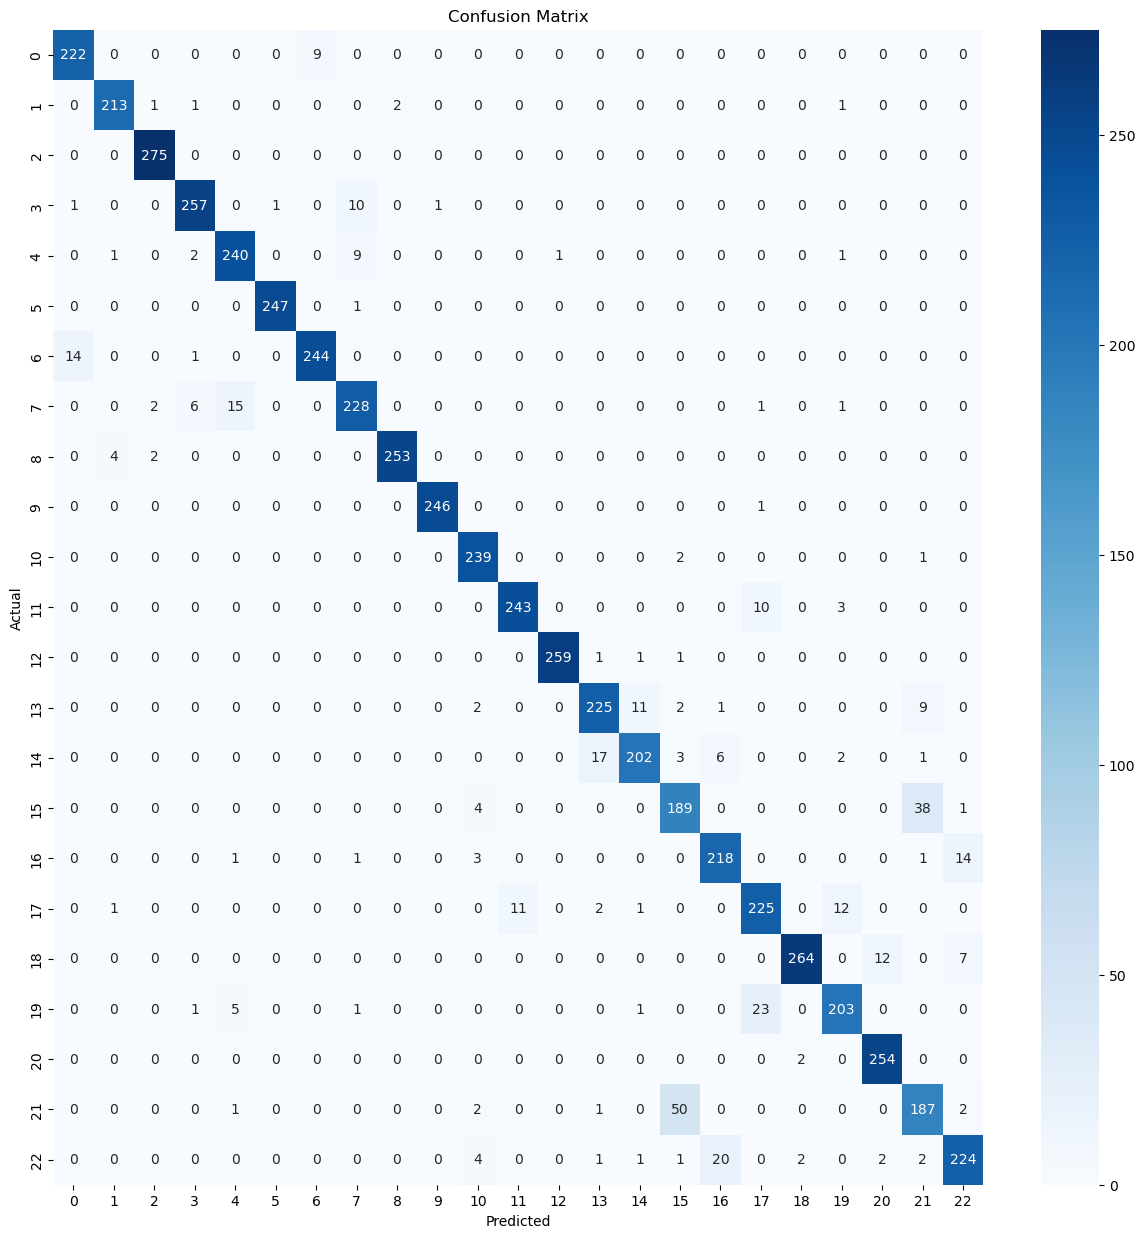

In [18]:
print_confusion_matrix(y_test, y_pred_lr)

In logistic regression models, the *Odds Ratio* is on way of telling how the feature affects the odds of the outcome: when the Odds Ratio is greater than one, the feature increases the odds of the outcome. If the Odds Ratio is negative, it decreases the odds. And if the Odds Ratio is 1, the feature doesn't affect the odds of the outcome.

The *Coefficient Magnitude* also tells about the feature's effect on the odds: if the Coefficient is **negative**, the odds of the sample being the substance in question **decrease**. And if the Coefficient is **positive**, the odds of the sample being the substance in question **increase**.

In [72]:
# for i, c in enumerate(lr_model.coef_):
#     plt.figure().set_size_inches(15,5)
#     plt.subplot(1, 2, 1)
#     plt.grid(visible=True, alpha=0.6)
#     plt.ylim(-6, 6)
#     plt.title(f"Coefficients {folders[i]}")
#     plt.axhline(y = 0, color='gray')
#     plt.plot(wavelengths, c)

#     plt.subplot(1, 2, 2)
#     plt.grid(visible=True, alpha=0.6)
#     plt.title(f"Odds Ratios {folders[i]}")
#     plt.axhline(y = 0, color='gray')
#     plt.axhline(y = 1, color="red", linestyle="--")
#     plt.plot(wavelengths, np.exp(c))
#     plt.show()

## Stochastic gradient descent classifier

In [20]:
sgd_model = joblib.load('models/sgd_model.pkl')
# sgd_model = SGDClassifier(random_state=4)

sgd_model.fit(X_train, y_train)

,loss,'modified_huber'
,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,3000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [21]:
y_pred_sgd = estimate_model(sgd_model, X_test, y_test)

accuracy: 0.82
              precision    recall  f1-score   support

           0       0.83      0.84      0.83       231
           1       0.93      0.91      0.92       218
           2       0.99      0.96      0.98       275
           3       0.93      0.79      0.86       270
           4       0.57      0.92      0.71       254
           5       0.97      0.92      0.94       248
           6       0.92      0.75      0.82       259
           7       0.81      0.64      0.71       253
           8       1.00      0.96      0.98       259
           9       1.00      0.99      0.99       247
          10       0.95      0.93      0.94       242
          11       0.91      0.91      0.91       256
          12       1.00      0.98      0.99       262
          13       0.72      0.62      0.67       250
          14       0.81      0.76      0.79       231
          15       0.70      0.52      0.60       232
          16       0.84      0.84      0.84       238
          17

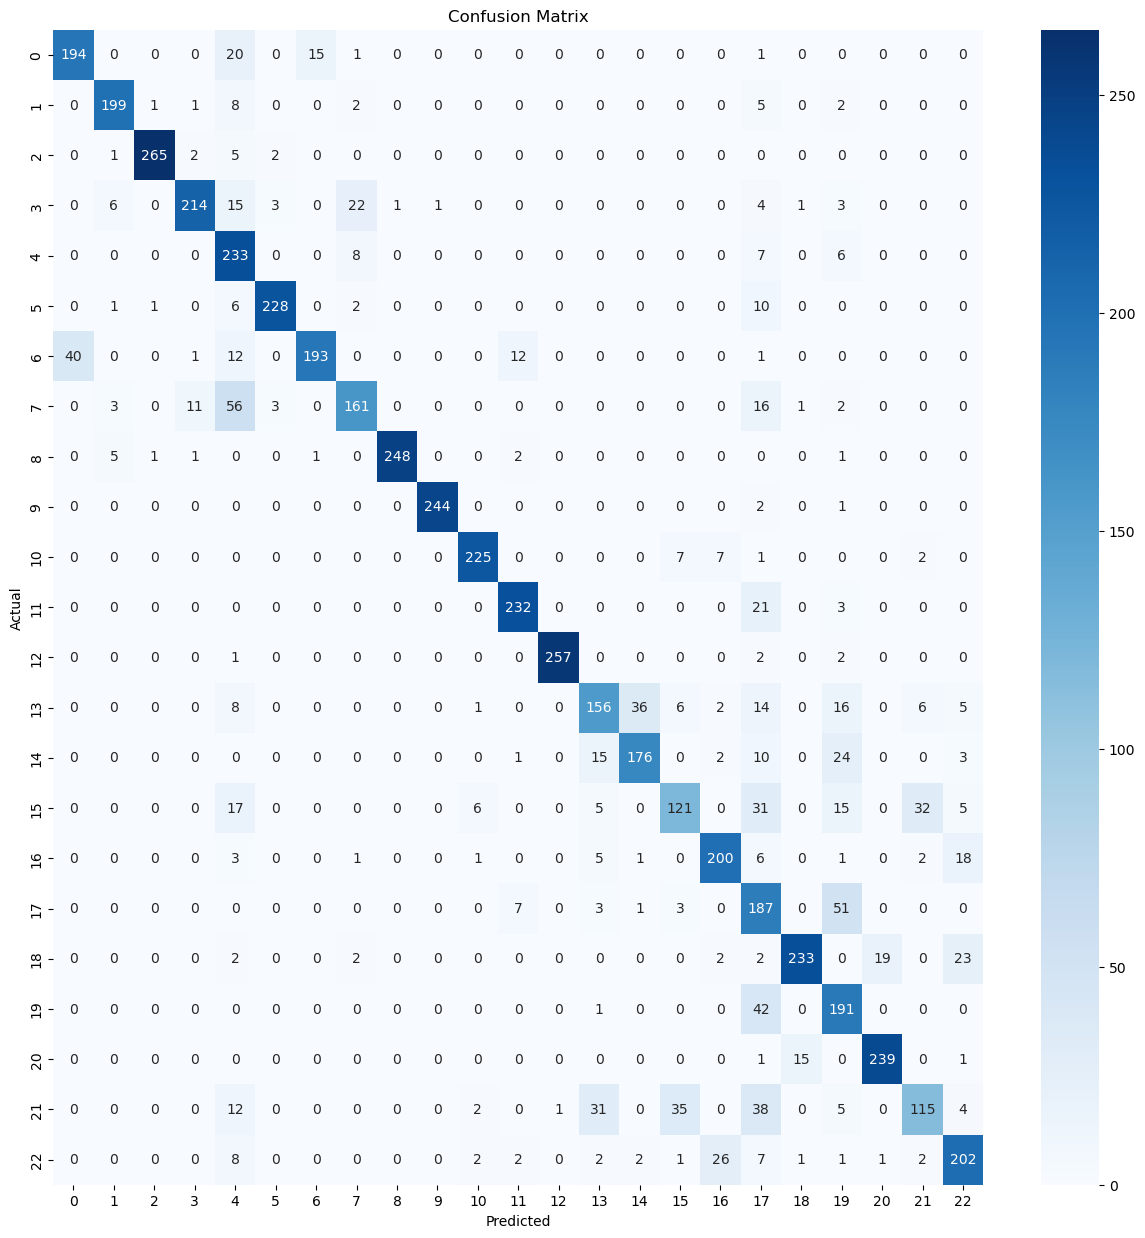

In [22]:
print_confusion_matrix(y_test, y_pred_sgd)

## K-nearest neighbors

In [23]:
knn_model = joblib.load('models/knn_model.pkl')
# knn_model = KNNClassifier(random_state=4)

knn_model.fit(X_train, y_train)

,n_neighbors,4
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
y_pred_knn = estimate_model(knn_model, X_test, y_test)

accuracy: 0.82
              precision    recall  f1-score   support

           0       0.69      0.77      0.73       231
           1       0.62      0.56      0.59       218
           2       0.95      0.96      0.95       275
           3       0.65      0.64      0.64       270
           4       0.74      0.78      0.76       254
           5       0.75      0.90      0.82       248
           6       0.76      0.70      0.73       259
           7       0.62      0.62      0.62       253
           8       0.97      0.92      0.94       259
           9       0.98      0.98      0.98       247
          10       0.91      0.97      0.94       242
          11       0.91      0.91      0.91       256
          12       0.91      0.97      0.94       262
          13       0.81      0.84      0.83       250
          14       0.94      0.73      0.82       231
          15       0.74      0.88      0.80       232
          16       0.78      0.69      0.73       238
          17

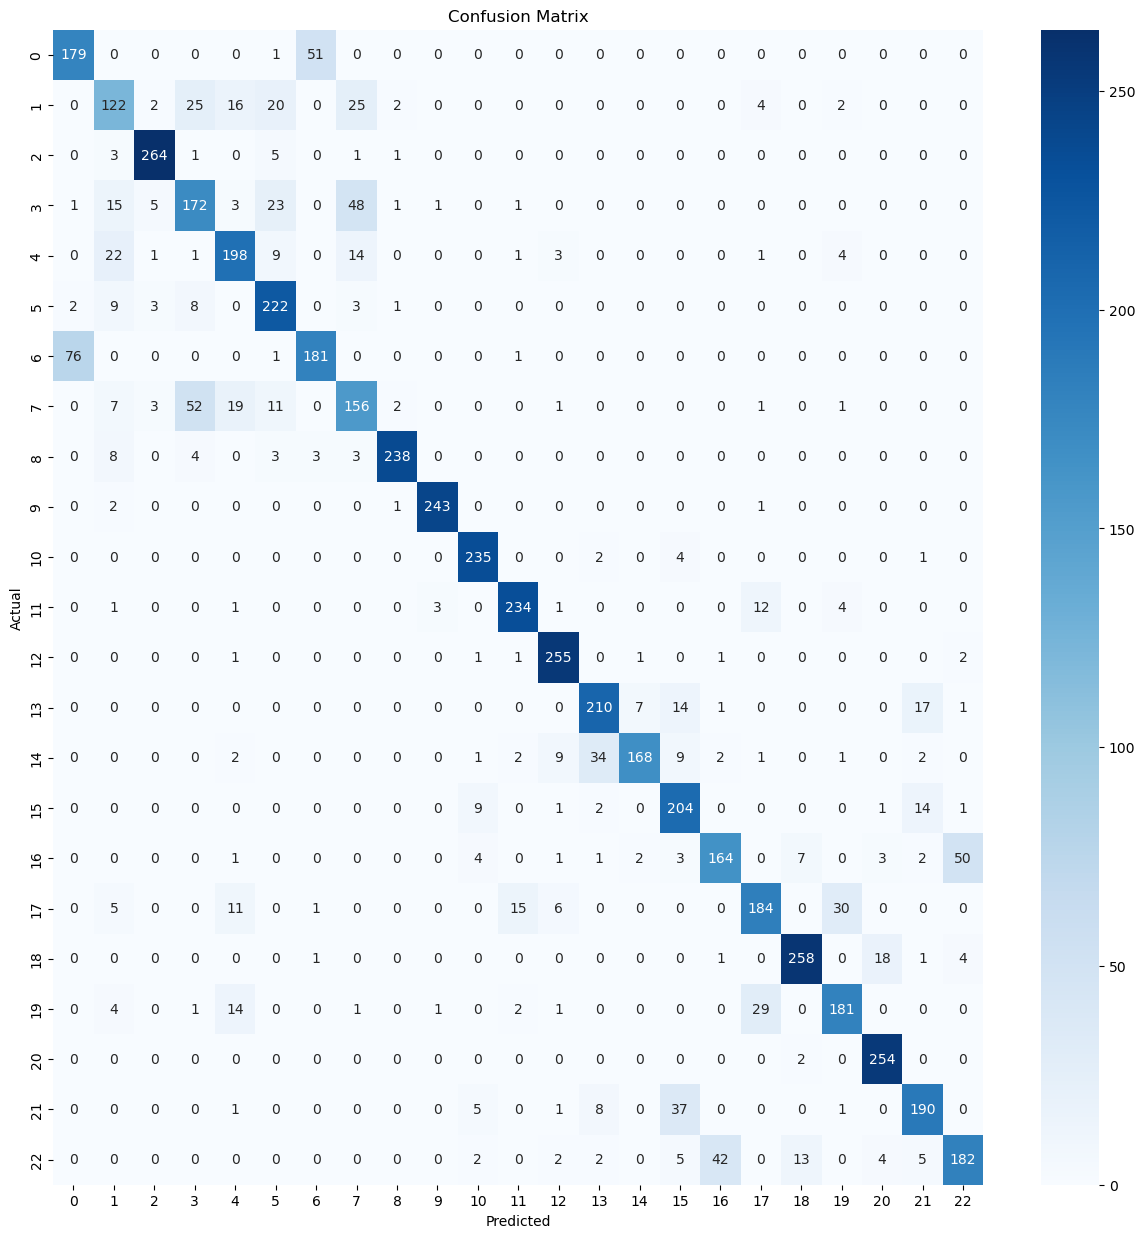

In [25]:
print_confusion_matrix(y_test, y_pred_knn)

## SVC

In [26]:
svc_model = joblib.load('models/svc_model.pkl')
# svc_model = SVC(random_state=4)

svc_model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [27]:
y_pred_svc = estimate_model(svc_model, X_test, y_test)

accuracy: 0.94
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       231
           1       0.98      0.98      0.98       218
           2       0.99      1.00      1.00       275
           3       0.97      0.97      0.97       270
           4       0.92      0.96      0.94       254
           5       0.99      1.00      0.99       248
           6       0.96      0.96      0.96       259
           7       0.94      0.92      0.93       253
           8       1.00      0.99      0.99       259
           9       1.00      1.00      1.00       247
          10       0.96      0.99      0.97       242
          11       0.97      0.95      0.96       256
          12       1.00      1.00      1.00       262
          13       0.91      0.92      0.92       250
          14       0.96      0.88      0.92       231
          15       0.82      0.79      0.81       232
          16       0.89      0.94      0.91       238
          17

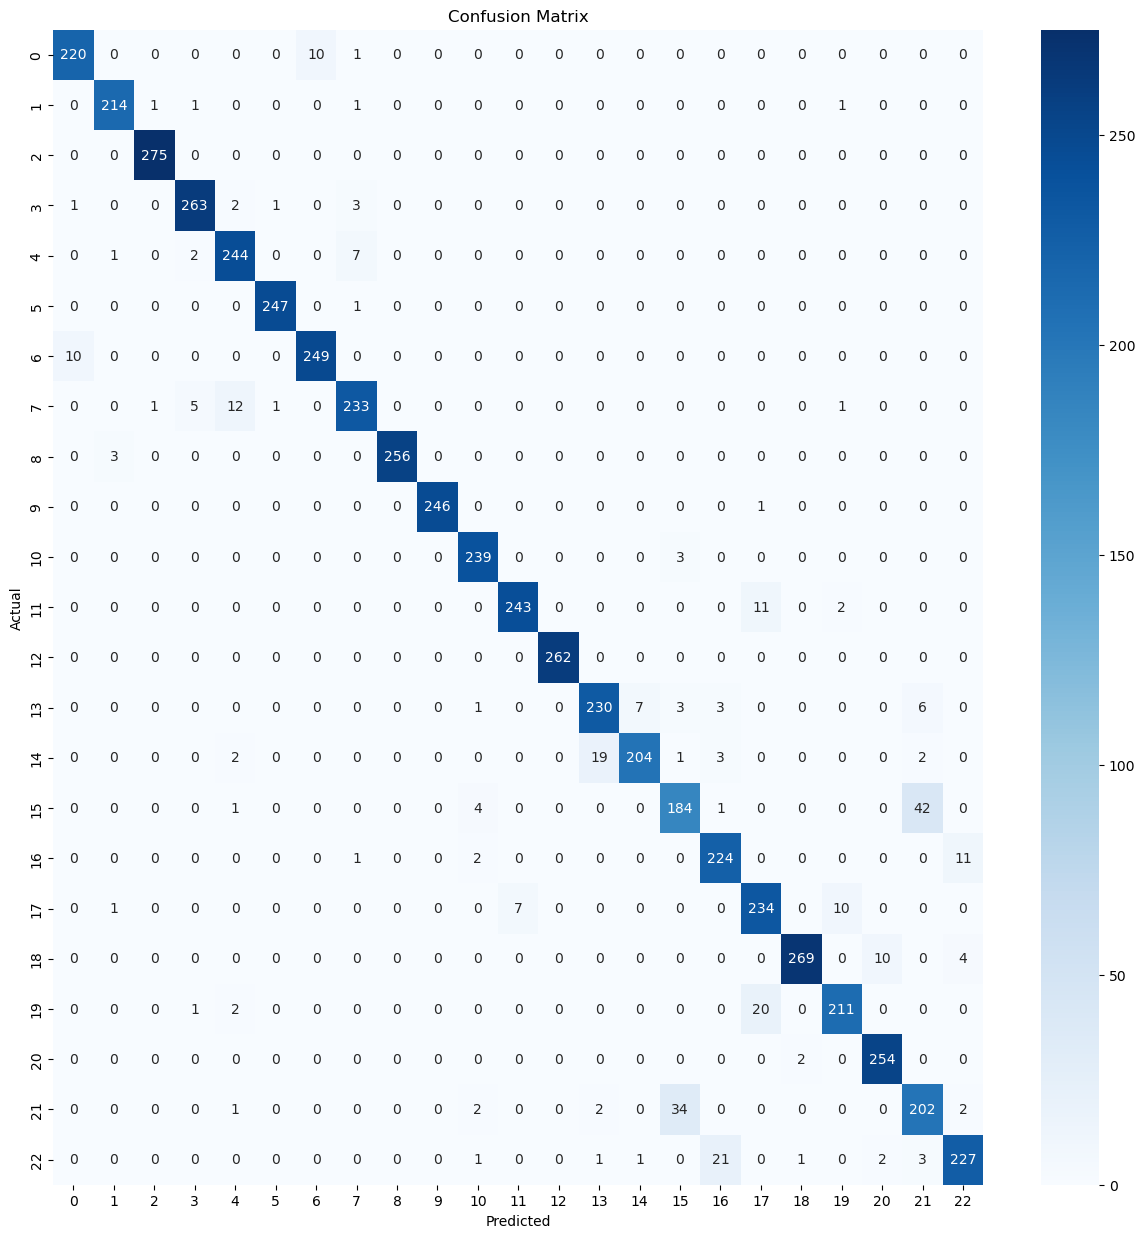

In [28]:
print_confusion_matrix(y_test, y_pred_svc)

## Random forest

In [29]:
rf_model = joblib.load('models/rf_model.pkl')
# rf_model = RandomForestClassifier(random_state=4)

rf_model.fit(X_train, y_train)

,n_estimators,50
,criterion,'entropy'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_pred_rf = estimate_model(rf_model, X_test, y_test)

accuracy: 0.82
              precision    recall  f1-score   support

           0       0.64      0.88      0.74       231
           1       0.68      0.61      0.64       218
           2       0.96      0.98      0.97       275
           3       0.69      0.70      0.70       270
           4       0.74      0.77      0.76       254
           5       0.76      0.90      0.83       248
           6       0.85      0.59      0.70       259
           7       0.65      0.56      0.60       253
           8       0.93      0.90      0.92       259
           9       1.00      0.99      0.99       247
          10       0.90      0.98      0.93       242
          11       0.88      0.89      0.88       256
          12       0.87      0.98      0.92       262
          13       0.86      0.85      0.85       250
          14       0.94      0.81      0.87       231
          15       0.77      0.80      0.79       232
          16       0.78      0.68      0.73       238
          17

Below is a graph of the feature importances of the random forest classifier. Feature importances measures how much each feature reduces impurity in the decision trees.

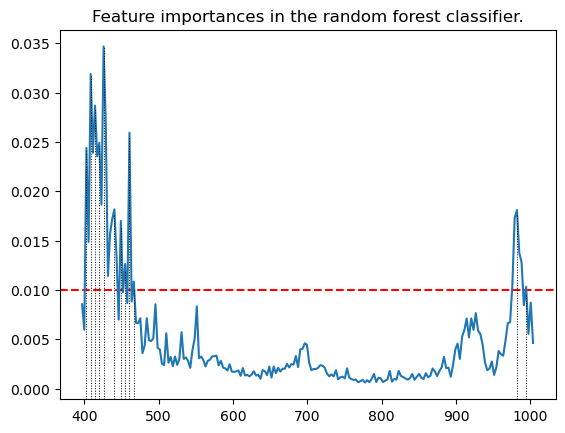

In [31]:
plt.axhline(y = 0.01, linestyle = "--", color = "red")
peaks, _ = find_peaks(rf_model.feature_importances_, height=0.01)
plt.plot(wavelengths, rf_model.feature_importances_)
_, _, _, ymax = plt.axis()
for x in peaks:
    plt.axvline(x=wavelengths[x], ymax=rf_model.feature_importances_[x]/ymax, color="black", linestyle=":", lw=0.7)
plt.title("Feature importances in the random forest classifier.")
plt.show()

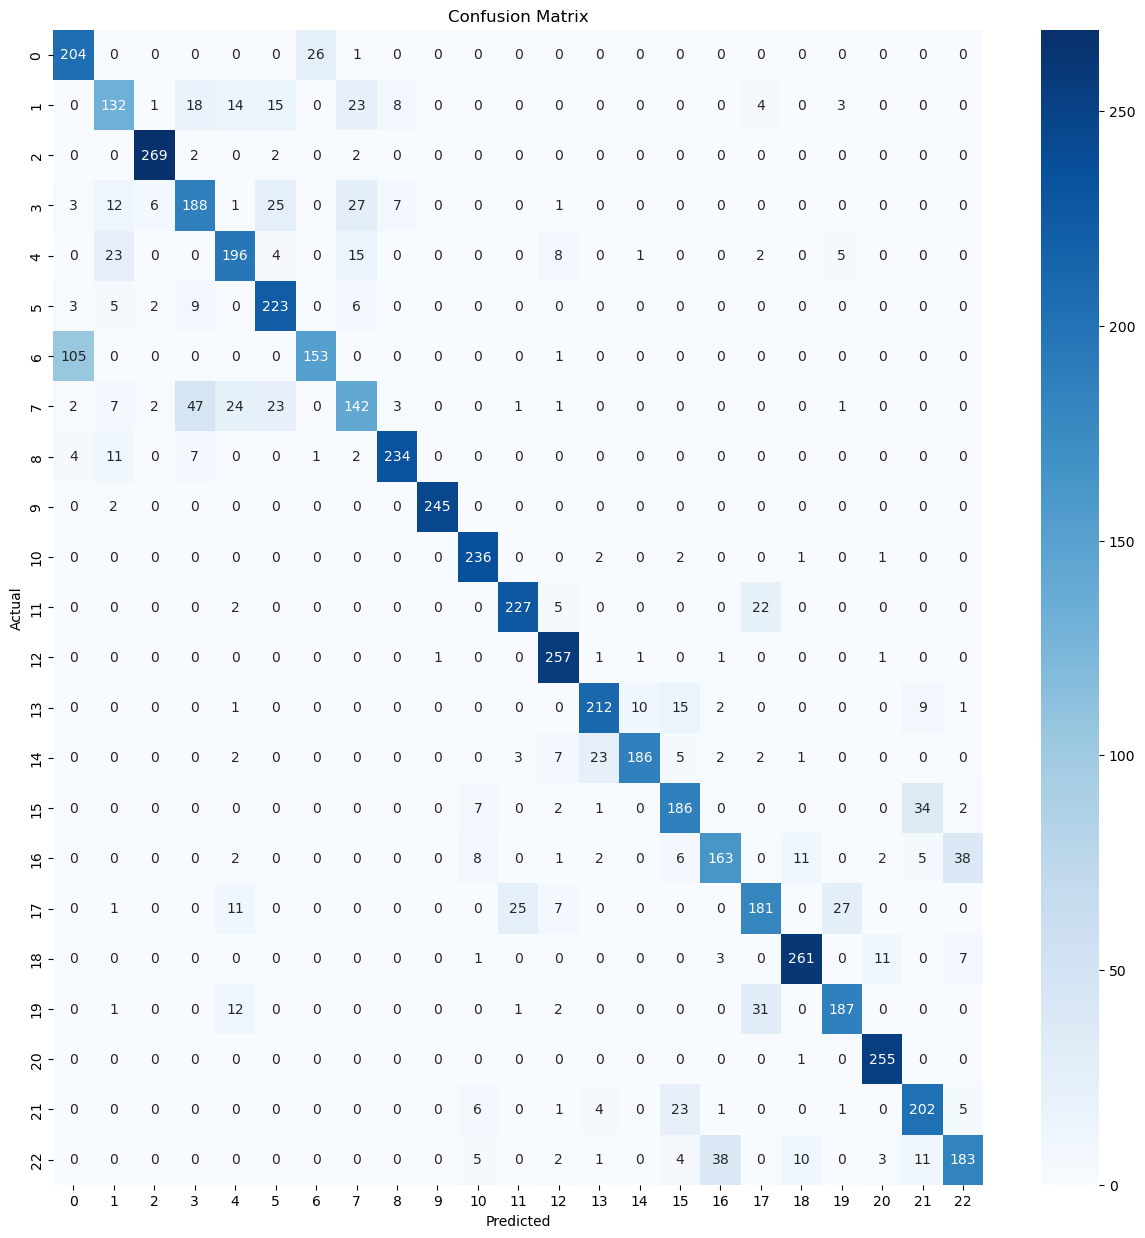

In [32]:
print_confusion_matrix(y_test, y_pred_rf)

## Neural networks

Neural networks are more complicated machine learning algoritms than the ones used previously. They are inspired by the human brain, and consist of layers, which inturn consist of neurons. Neural networks usually have three different kinds of layers: an input layer, one or more hidden layers, and an output layer.

<br>

In this notebook, a Python library called TensorFlow is used to form and train neural networks on the hyperspectral data. Other Python libraries for neural networks are for example PyTorch and MXNet.

The first neural network consists of four layers: An input layer, where the input is defined to have 204 features (the different wavelengths measured). Two hidden layers, the first of which has 64 neurons and the second 32. And lastly, an output layer, which outputs 23 different probabilities between 0 and 1 that all sum up to 1, one for each of the sampled substances.

<br>

The neural network can be adjusted by adding or removing layers, or adjusting the amount of neurons in them (except for the last layer).

In [33]:
nn_model = tf.keras.Sequential()
nn_model.add(tf.keras.layers.InputLayer(shape=[204]))
nn_model.add(tf.keras.layers.Dense(64, activation='relu'))
nn_model.add(tf.keras.layers.Dense(32, activation='relu'))
nn_model.add(tf.keras.layers.Dense(23, activation='softmax'))

I0000 00:00:1788852983.216334 1321839 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10029 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:17:00.0, compute capability: 8.6
I0000 00:00:1788852983.236624 1321839 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 3089 MB memory:  -> device: 1, name: NVIDIA RTX A4000, pci bus id: 0000:65:00.0, compute capability: 8.6


In [34]:
nn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        13,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,959 (62.34 KB)

 Trainable params: 15,959 (62.34 KB)

 Non-trainable params: 0 (0.00 B)

Another way to affect the accuracy of the model is to adjust the amount of epochs below. Epochs are the training cycles of the model.

In [35]:
nn_model.fit(X_train, y_train, epochs=100, verbose=0)

I0000 00:00:1788852989.551225 1322481 service.cc:153] XLA service 0x7f57580328e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788852989.551244 1322481 service.cc:161]   StreamExecutor [0]: NVIDIA RTX A4000, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.23.1)
I0000 00:00:1788852989.551250 1322481 service.cc:161]   StreamExecutor [1]: NVIDIA RTX A4000, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.23.1)
I0000 00:00:1788852990.245667 1322481 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788852990.745581 1322481 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1788852990.951976 1322481 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1228__.13
I0000 00:00:1788852992.673182 1322481 dot_search_space.cc:240] All configs were filtered out because none of th

In [36]:
test_loss, test_acc = nn_model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")

180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9339 - loss: 0.2165
Test accuracy: 0.9339130520820618


In [37]:
nn_model.metrics_variables

[<Variable path=loss/total, shape=(), dtype=float32, value=1244.8974609375>,
 <Variable path=loss/count, shape=(), dtype=float32, value=5750.0>,
 <Variable path=accuracy/total, shape=(), dtype=float32, value=5370.0>,
 <Variable path=accuracy/count, shape=(), dtype=float32, value=5750.0>]

A Sequential TensorFlow neural network model can be saved using `tensorflow.keras.Sequential.save("filename")` as a Python file.

# The mixed samples

The `kitchen` and `kitchenday2` folders also include 4 images with 6 different substances per image. Unfortunately, these images have something wrong with the reflectances, so, as you can see in the graph below, the reflectances are far from those in the single-substance images. This unfortunately means that the machine learning models do not perfom well in classifying the substances in the images.

In [75]:
c, _ = load_and_compute_reflectance(PATH, 'kitchen/sekoite1/', '055')

/tmp/ipykernel_1321839/3144728661.py:91: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_1321839/3144728661.py:95: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


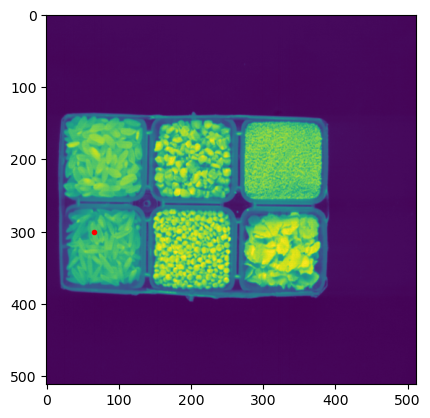

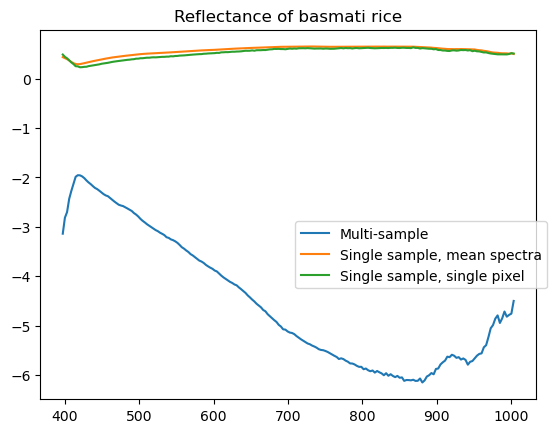

In [86]:
p = [c[65,300,:], c[75,310,:], c[80,310,:], c[70,315,:], c[75,340,:]]
p = scaler.transform(p)
t = [0, 0, 0, 0, 0]

plt.scatter(65,300, color="red", marker='.')
plt.imshow(c[:,:,150])
plt.show()

plt.plot(wavelengths, p[0])
plt.plot(wavelengths, spectra[0])
plt.plot(wavelengths, image_cubes[0][200, 200, :])
plt.title('Reflectance of basmati rice')
plt.legend(['Multi-sample', 'Single sample, mean spectra', 'Single sample, single pixel'], bbox_to_anchor=(0.5,0.5))
plt.show()

Below is the performance of the logistic regression classification model on the multi-sample image with 5 pixels.

In [48]:
y_pred_lr = estimate_model(lr_model, p, t)

accuracy: 0.0
              precision    recall  f1-score   support

           2       0.00      0.00      0.00       5.0
          10       0.00      0.00      0.00       0.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0



/home/anntarva/anaconda3/envs/py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/anntarva/anaconda3/envs/py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/anntarva/anaconda3/envs/py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

Another substance:

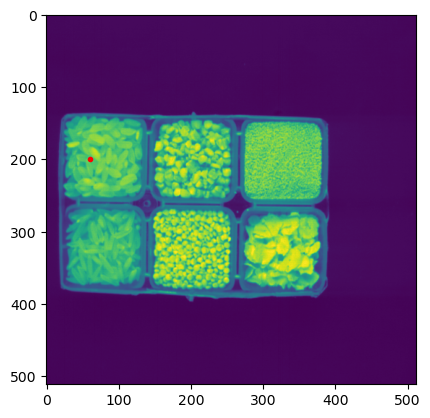

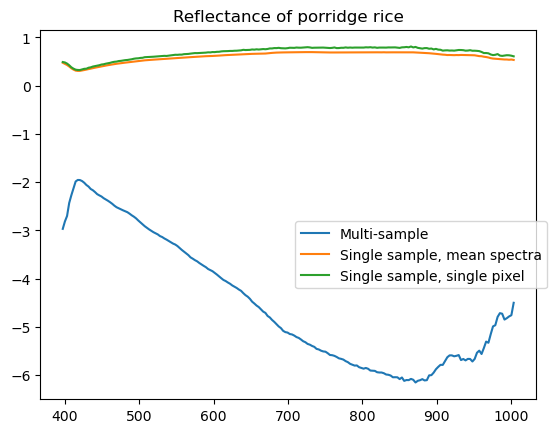

In [89]:
p = [c[60,200,:], c[100,190,:], c[90,210,:], c[95,200,:], c[50,215,:]]
p = scaler.transform(p)
t = [6,6,6,6,6]

plt.scatter(60,200, color="red", marker='.')
plt.imshow(c[:,:,150])
plt.show()

plt.plot(wavelengths, p[0])
plt.plot(wavelengths, spectra[6])
plt.plot(wavelengths, image_cubes[6][200, 200, :])
plt.title('Reflectance of porridge rice')
plt.legend(['Multi-sample', 'Single sample, mean spectra', 'Single sample, single pixel'], bbox_to_anchor=(0.5,0.5))
plt.show()

In [90]:
y_pred_lr = estimate_model(lr_model, p, t)

accuracy: 0.0
              precision    recall  f1-score   support

           6       0.00      0.00      0.00       5.0
          10       0.00      0.00      0.00       0.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0



/home/anntarva/anaconda3/envs/py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/anntarva/anaconda3/envs/py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/anntarva/anaconda3/envs/py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

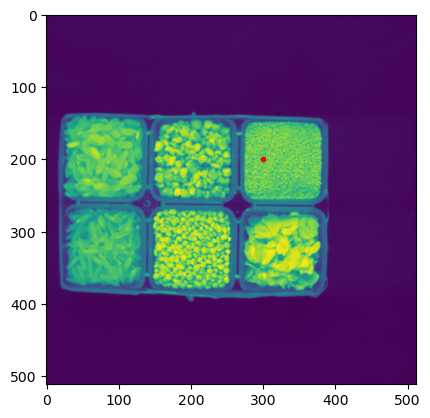

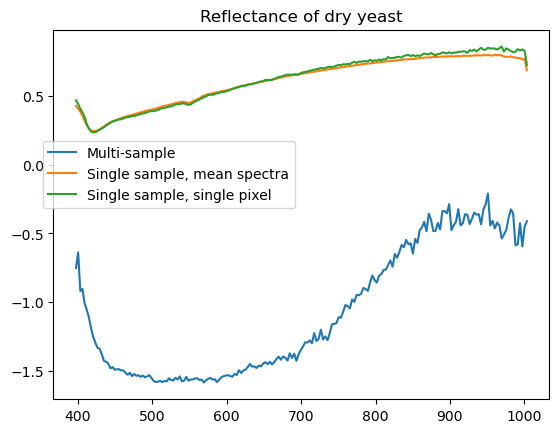

In [96]:
p = [c[300,200,:], c[350,220,:], c[340,210,:], c[355,200,:], c[310,215,:]]
p = scaler.transform(p)
t = [2,2,2,2,2]

plt.scatter(300,200, color="red", marker='.')
plt.imshow(c[:,:,150])
plt.show()

plt.plot(wavelengths, p[0])
plt.plot(wavelengths, spectra[2])
plt.plot(wavelengths, image_cubes[2][200, 200, :])
plt.title('Reflectance of dry yeast')
plt.legend(['Multi-sample', 'Single sample, mean spectra', 'Single sample, single pixel'], bbox_to_anchor=(0.5,0.5))
plt.show()

In [95]:
y_pred_lr = estimate_model(lr_model, p, t)

accuracy: 0.0
              precision    recall  f1-score   support

           2       0.00      0.00      0.00       5.0
           3       0.00      0.00      0.00       0.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0



/home/anntarva/anaconda3/envs/py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/anntarva/anaconda3/envs/py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/anntarva/anaconda3/envs/py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

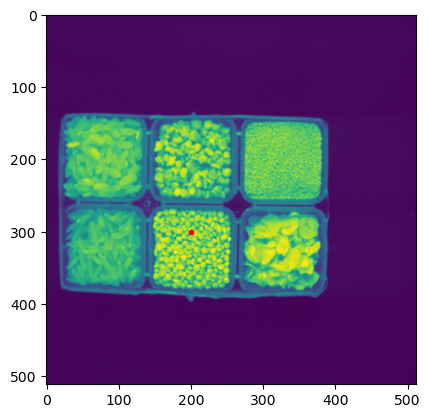

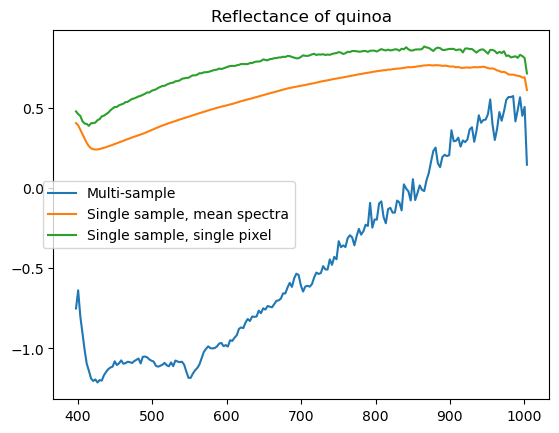

In [99]:
p = [c[200,300,:], c[210,330,:], c[205,315,:], c[190,290,:], c[195,330,:]]
p = scaler.transform(p)
t = [3,3,3,3,3]

plt.scatter(200,300, color="red", marker='.')
plt.imshow(c[:,:,150])
plt.show()

plt.plot(wavelengths, p[0])
plt.plot(wavelengths, spectra[3])
plt.plot(wavelengths, image_cubes[3][200, 200, :])
plt.title('Reflectance of quinoa')
plt.legend(['Multi-sample', 'Single sample, mean spectra', 'Single sample, single pixel'], bbox_to_anchor=(0.5,0.5))
plt.show()

In [100]:
y_pred_lr = estimate_model(lr_model, p, t)

accuracy: 0.0
              precision    recall  f1-score   support

           2       0.00      0.00      0.00       0.0
           3       0.00      0.00      0.00       5.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0



/home/anntarva/anaconda3/envs/py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/anntarva/anaconda3/envs/py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/anntarva/anaconda3/envs/py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap